# part 1

In [36]:
# !pip install openpyxl

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [38]:
fp_avail="gs://agntworks-data-dev/sandbox/experiments/Available Flights Last 18 mos.xlsx"
fp_comp="gs://agntworks-data-dev/sandbox/experiments/Completed-Flights-2016.xlsx"
fp_quotes="gs://agntworks-data-dev/sandbox/experiments/XODM-quotes-trips-2016.xlsx"

avail = pd.read_excel(fp_avail)
completed = pd.read_excel(fp_comp)
quotes_2016 = pd.read_excel(fp_quotes, sheet_name='2016')

In [39]:
# Quick schema + sample
for name, df in [('avail', avail), ('completed', completed), ('quotes_2016', quotes_2016)]:
    print('\n' + '='*90)
    print(name, df.shape)
    print('Columns:', list(df.columns))
    display(df.head(5))
    # missingness top 15
    miss = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
    display(miss.head(15).to_frame('missing_%'))
    # dtypes
    display(df.dtypes.to_frame('dtype').T)



avail (552, 3)
Columns: ['date', 'sold', 'available']


,date,sold,available
0,2015-01-12,19,1
1,2015-01-13,17,2
2,2015-01-14,23,1
3,2015-01-15,29,0
4,2015-01-16,33,3


,missing_%
date,0.0
sold,0.0
available,0.0


,date,sold,available
dtype,datetime64[ns],int64,int64



completed (12806, 32)
Columns: ['Quote_Number', 'Trip_Number', 'Trip_Legs_ID', 'Leg_Count', 'Leg_Number', 'DHflag', 'PAX_Count', 'Dep_ICAO', 'Dep_Lat', 'Dep_Long', 'Dep_region', 'Arr_ICAO', 'Arr_Lat', 'Arr_Long', 'Arr_region', 'Trip_type_code', 'Trip_Purpose', 'Aircraft_ID', 'Aircraft_Type_ID', 'Dep_Date_Actual_GMT', 'Dep_Time_Actual_GMT', 'Arr_Date_Actual_GMT', 'Arr_Time_Actual_GMT', 'TO_Time_Act_GMT', 'Land_Time_Act_GMT', 'Statute_Miles', 'Quote_Total_Cost', 'Equivalent_Rate_Cost', 'AC_Cost_Total', 'Owner_AC_Cost', 'Owner_AC_Cost_Fixed', 'Requester_Name_Key']


...

,Quote_Number,Trip_Number,Trip_Legs_ID,Leg_Count,Leg_Number,DHflag,PAX_Count,Dep_ICAO,Dep_Lat,Dep_Long,...,Arr_Time_Actual_GMT,TO_Time_Act_GMT,Land_Time_Act_GMT,Statute_Miles,Quote_Total_Cost,Equivalent_Rate_Cost,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed,Requester_Name_Key
dtype,int64,int64,object,int64,int64,int64,int64,object,int64,int64,...,object,object,object,int64,float64,float64,float64,float64,int64,object



quotes_2016 (22708, 59)
Columns: ['ID', 'Quote_ID', 'Confirmation_Number', 'Date_Quoted', 'PAX_ID', 'Trip_ID', 'Trip_KID_Date', 'Trip_Number', 'Trip_Status', 'qTrip_type_code', 'tRate_Type_Code', 'tDivision', 'tDept', 'Reason_Not_Booked', 'qRate_Type_Code', 'Trip_Purpose', 'Aircraft_Type_ID', 'Invoice_Number', 'Paid', 'Invoiced', 'Approved', 'Confirmed', 'Scheduled', 'Quoted_For_Company', 'Quote_Total_Cost', 'ETE_Quote', 'EFT_Quote', 'PaxFT', 'DHFT', 'tripBT', 'tripFT', 'Aircraft_ID', 'Company_Code', 'Scheduled_Date', 'Trip_Departure_Date', 'Trip_Arrival_Date', 'Percent_Discount', 'Quote_Status', 'Quoted_Route', 'Live_Leg_City_Pairs', 'Invoice_Date', 'Equivalent_Rate_Cost', 'Aircraft_Company_Code', 'Aircraft_Rate', 'DHRate', 'DHFT.1', 'DHBT', 'DHTaxi', 'Aircraft_Cost_Rate_Ft', 'Pass_FT_Fixed', 'Client_Invoice_Comment', 'Base_Code', 'Last_Update_Date', 'Payment_1', 'Payment_Date_1', 'Payment_Type_1', 'AC_Cost_Total', 'Owner_AC_Cost', 'Owner_AC_Cost_Fixed']


,ID,Quote_ID,Confirmation_Number,Date_Quoted,PAX_ID,Trip_ID,Trip_KID_Date,Trip_Number,Trip_Status,qTrip_type_code,...,Pass_FT_Fixed,Client_Invoice_Comment,Base_Code,Last_Update_Date,Payment_1,Payment_Date_1,Payment_Type_1,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed
0,362002,423681001GEOA08,568956,2015-12-31,3939244FOUL1871,0,NaT,NaN,NaN,RETA,...,0,0,0,2015-12-31,0.0,NaT,0,24000.0,0.0,0
1,362003,423681017GEOA08,568957,2015-12-31,421851225STEB01,423681017GEOA015,2015-12-31,174284.0,Cancelled,WHSL,...,0,0,0,2016-01-01,0.0,NaT,0,0.0,0.0,0
2,362005,423681029GEOA08,568958,2015-12-31,41210923STEB01,0,NaT,NaN,NaN,RETA,...,0,0,120,2015-12-31,0.0,NaT,0,72750.0,0.0,0
3,362004,423681030SERD08,568959,2015-12-31,39552284MURC01,423681030SERD015,2015-12-31,174295.0,Completed,WHSL,...,0,0,0,2016-01-13,12937.5,2016-01-06,102,20350.0,0.0,0
4,362006,423681055GEOA08,568960,2015-12-31,415961361GEOA01,0,NaT,NaN,NaN,RETA,...,0,0,120,2015-12-31,0.0,NaT,0,38850.0,0.0,0


,missing_%
tRate_Type_Code,99.9
Reason_Not_Booked,95.4
Payment_Date_1,82.2
Trip_KID_Date,72.7
Trip_Status,72.7
tDivision,72.7
tDept,72.7
tripFT,72.7
tripBT,72.7
Trip_Number,72.7


,ID,Quote_ID,Confirmation_Number,Date_Quoted,PAX_ID,Trip_ID,Trip_KID_Date,Trip_Number,Trip_Status,qTrip_type_code,...,Pass_FT_Fixed,Client_Invoice_Comment,Base_Code,Last_Update_Date,Payment_1,Payment_Date_1,Payment_Type_1,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed
dtype,int64,object,int64,datetime64[ns],object,object,datetime64[ns],float64,object,object,...,int64,int64,int64,datetime64[ns],float64,datetime64[ns],int64,float64,float64,int64


In [40]:
def _to_timedelta(s: pd.Series) -> pd.Series:
    # Handles strings like '02:44:00' and missing values
    return pd.to_timedelta(s.astype('string'), errors='coerce')


completed_leg = completed.copy()

# Parse actual departure/arrival datetimes (date + time), both are in GMT fields
completed_leg['Dep_DT_GMT'] = pd.to_datetime(completed_leg['Dep_Date_Actual_GMT']) + _to_timedelta(completed_leg['Dep_Time_Actual_GMT'])
completed_leg['Arr_DT_GMT'] = pd.to_datetime(completed_leg['Arr_Date_Actual_GMT']) + _to_timedelta(completed_leg['Arr_Time_Actual_GMT'])

# Compute block time per leg (minutes); negative/zero becomes NaN (data issues / midnight crossover mishandling)
block_min = (completed_leg['Arr_DT_GMT'] - completed_leg['Dep_DT_GMT']).dt.total_seconds() / 60
completed_leg['Block_Min'] = block_min.where(block_min > 0)

# Basic numeric sanity
for c in ['Statute_Miles', 'PAX_Count', 'DHflag', 'Leg_Number', 'Leg_Count']:
    completed_leg[c] = pd.to_numeric(completed_leg[c], errors='coerce')

# --- Aggregate to trip level (Trip_Number) ---
# We use sums for distance/time and max for leg_count; pax is tricky leg-level, use max as proxy for trip pax load.
trip_agg = (
    completed_leg
    .groupby('Trip_Number', dropna=False)
    .agg(
        n_legs=('Trip_Legs_ID', 'nunique'),
        leg_count_max=('Leg_Count', 'max'),
        miles_total=('Statute_Miles', 'sum'),
        block_min_total=('Block_Min', 'sum'),
        pax_max=('PAX_Count', 'max'),
        dh_legs=('DHflag', 'sum'),
        miles_dh=('Statute_Miles', lambda x: x[completed_leg.loc[x.index, 'DHflag'].fillna(0).astype(int)==1].sum()),
        dep_dt_min=('Dep_DT_GMT', 'min'),
        arr_dt_max=('Arr_DT_GMT', 'max'),
        dep_icao_first=('Dep_ICAO', 'first'),
        arr_icao_last=('Arr_ICAO', 'last'),
        trip_type_code=('Trip_type_code', 'first'),
        trip_purpose=('Trip_Purpose', 'first'),
        aircraft_type_id=('Aircraft_Type_ID', 'first'),
        aircraft_id=('Aircraft_ID', 'first'),
        quote_total_cost=('Quote_Total_Cost', 'first'),
        eq_rate_cost=('Equivalent_Rate_Cost', 'first'),
        ac_cost_total=('AC_Cost_Total', 'first'),
        owner_ac_cost=('Owner_AC_Cost', 'first'),
    )
    .reset_index()
)

# Derived operational ratios (often key pricing levers)
trip_agg['dh_share_miles'] = (trip_agg['miles_dh'] / trip_agg['miles_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['block_hr_total'] = trip_agg['block_min_total'] / 60
trip_agg['speed_mph'] = (trip_agg['miles_total'] / (trip_agg['block_hr_total'])).replace([np.inf, -np.inf], np.nan)
trip_agg['cost_per_mile_actual'] = (trip_agg['quote_total_cost'] / trip_agg['miles_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['cost_per_block_hr_actual'] = (trip_agg['quote_total_cost'] / trip_agg['block_hr_total']).replace([np.inf, -np.inf], np.nan)
trip_agg['margin_vs_ac_cost'] = trip_agg['quote_total_cost'] - trip_agg['ac_cost_total']
trip_agg['margin_pct_vs_ac_cost'] = (trip_agg['margin_vs_ac_cost'] / trip_agg['quote_total_cost']).replace([np.inf, -np.inf], np.nan)

# Add calendar fields (seasonality is a common aviation pricing driver)
trip_agg['dep_date'] = trip_agg['dep_dt_min'].dt.date
trip_agg['dep_month'] = trip_agg['dep_dt_min'].dt.to_period('M').astype('string')
trip_agg['dep_dow'] = trip_agg['dep_dt_min'].dt.day_name()

# --- Join to quotes_2016 for quote/status fields (trip-level) ---
quotes_trip = quotes_2016.copy()
quotes_trip['Trip_Number'] = pd.to_numeric(quotes_trip['Trip_Number'], errors='coerce')

# One Trip_Number can appear multiple times in quotes (re-quotes, updates). Keep latest by Last_Update_Date.
quotes_trip = quotes_trip.sort_values('Last_Update_Date').drop_duplicates(subset=['Trip_Number'], keep='last')

trip = trip_agg.merge(
    quotes_trip[[
        'Trip_Number','Trip_Status','Date_Quoted','Scheduled_Date','Trip_Departure_Date','Trip_Arrival_Date',
        'Percent_Discount','Quote_Status','Quoted_Route','Live_Leg_City_Pairs','qTrip_type_code','qRate_Type_Code',
        'Aircraft_Rate','DHRate','Company_Code','Quoted_For_Company'
    ]],
    on='Trip_Number',
    how='left'
)

# Quick preview
print('Trip-level dataset:', trip.shape)
display(trip.head(5))

# Basic missingness for key analysis fields
key_cols = [
    'miles_total','block_hr_total','pax_max','dh_share_miles','quote_total_cost','ac_cost_total','margin_pct_vs_ac_cost',
    'Trip_Status','Quote_Status','Percent_Discount','qRate_Type_Code','Aircraft_Rate','DHRate','dep_month'
]
miss_key = (trip[key_cols].isna().mean().sort_values(ascending=False) * 100).round(1)
display(miss_key.to_frame('missing_%'))

# Sanity summaries for potential anomalies
summ = trip[['miles_total','block_hr_total','speed_mph','dh_share_miles','cost_per_mile_actual','margin_pct_vs_ac_cost']].describe(percentiles=[.01,.05,.5,.95,.99]).T
summ = summ.round(3)
display(summ)

Trip-level dataset: (6167, 45)


,Trip_Number,n_legs,leg_count_max,miles_total,block_min_total,pax_max,dh_legs,miles_dh,dep_dt_min,arr_dt_max,...,Percent_Discount,Quote_Status,Quoted_Route,Live_Leg_City_Pairs,qTrip_type_code,qRate_Type_Code,Aircraft_Rate,DHRate,Company_Code,Quoted_For_Company
0,157565,3,3,4382,698.0,4,1,1227,2016-01-01 23:37:00,2016-01-03 03:15:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,162215,6,7,6771,932.0,2,3,2501,2016-01-10 14:56:00,2016-01-17 23:16:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,162216,5,5,4583,626.0,2,1,163,2016-02-01 12:40:00,2016-02-11 22:12:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,162484,3,3,8211,950.0,9,0,0,2016-04-08 04:40:00,2016-04-18 00:30:00,...,0.0,Invoiced - Ready to Export,KOAK-MBPV MBPV-TVSC TVSC-KOAK,KOAK-MBPV MBPV-TVSC TVSC-KOAK,RETA,CHTR,9071.39,0.0,1.0,MacGregor & Mary Read Revocable Trust - PRF6
4,165417,1,1,1528,183.0,16,0,0,2016-01-02 18:42:00,2016-01-02 21:45:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_%
margin_pct_vs_ac_cost,23.4
qRate_Type_Code,18.9
Trip_Status,18.6
Quote_Status,18.6
Aircraft_Rate,18.6
Percent_Discount,18.6
DHRate,18.6
dh_share_miles,2.4
ac_cost_total,0.0
block_hr_total,0.0


,count,mean,std,min,1%,5%,50%,95%,99%,max
miles_total,6167.0,1947.889,1644.349,0.000,0.00,146.900,1633.000,5138.000,6827.860,20510.000
block_hr_total,6167.0,4.778,3.638,0.000,0.00,0.800,4.067,11.662,15.817,47.850
speed_mph,6092.0,372.851,100.436,0.000,0.00,177.887,395.739,492.497,530.074,1101.496
dh_share_miles,6022.0,0.177,0.294,0.000,0.00,0.000,0.000,1.000,1.000,1.000
cost_per_mile_actual,6022.0,13.822,31.736,-0.281,0.00,0.000,12.084,31.399,60.443,1249.438
margin_pct_vs_ac_cost,4724.0,0.099,0.258,-2.911,-0.77,-0.409,0.170,0.366,0.474,1.000


In [41]:
num_cols = [
    'miles_total','block_hr_total','pax_max','dh_share_miles',
    'quote_total_cost','ac_cost_total','cost_per_mile_actual','cost_per_block_hr_actual',
    'margin_vs_ac_cost','margin_pct_vs_ac_cost','speed_mph','n_legs'
]
cat_cols = ['Trip_Status','Quote_Status','qTrip_type_code','qRate_Type_Code','trip_type_code','trip_purpose','dep_month','dep_dow']

# --- Basic duplicates / null sanity ---
print('Trip rows:', len(trip))
print('Unique Trip_Number:', trip['Trip_Number'].nunique())

# --- Numeric summaries with  percentiles ---
desc = trip[num_cols].describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]).T

desc['missing_%'] = (trip[num_cols].isna().mean()*100).round(2)
desc['zero_%'] = ((trip[num_cols]==0).mean()*100).round(2)

display(desc.round(3))

Trip rows: 6167
Unique Trip_Number: 6167


,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max,missing_%,zero_%
miles_total,6167.0,1947.889,1644.349,0.000,0.00,146.900,247.000,1633.000,4213.400,5138.000,6827.860,20510.000,0.00,2.35
block_hr_total,6167.0,4.778,3.638,0.000,0.00,0.800,1.083,4.067,9.783,11.662,15.817,47.850,0.00,1.22
pax_max,6167.0,3.424,2.618,0.000,0.00,0.000,0.000,3.000,7.000,8.000,10.000,21.000,0.00,10.54
dh_share_miles,6022.0,0.177,0.294,0.000,0.00,0.000,0.000,0.000,0.567,1.000,1.000,1.000,2.35,49.96
quote_total_cost,6167.0,25258.477,27896.820,-295.000,0.00,0.000,0.000,21974.000,54139.428,66748.493,99997.966,673872.350,0.00,23.40
ac_cost_total,6167.0,22380.436,24762.128,0.000,0.00,0.000,0.000,19408.500,45586.254,60953.817,89136.000,585380.020,0.00,23.56
cost_per_mile_actual,6022.0,13.822,31.736,-0.281,0.00,0.000,0.000,12.084,23.806,31.399,60.443,1249.438,2.35,21.06
cost_per_block_hr_actual,6092.0,4791.663,4270.404,-109.259,0.00,0.000,0.000,4944.820,8385.264,10089.259,16815.976,108923.782,1.22,22.20
margin_vs_ac_cost,6167.0,2878.041,7609.936,-37400.000,-15845.22,-8078.560,-4577.942,1754.010,11768.226,15979.589,23974.693,123472.550,0.00,23.43
margin_pct_vs_ac_cost,4724.0,0.099,0.258,-2.911,-0.77,-0.409,-0.212,0.170,0.323,0.366,0.474,1.000,23.40,0.03


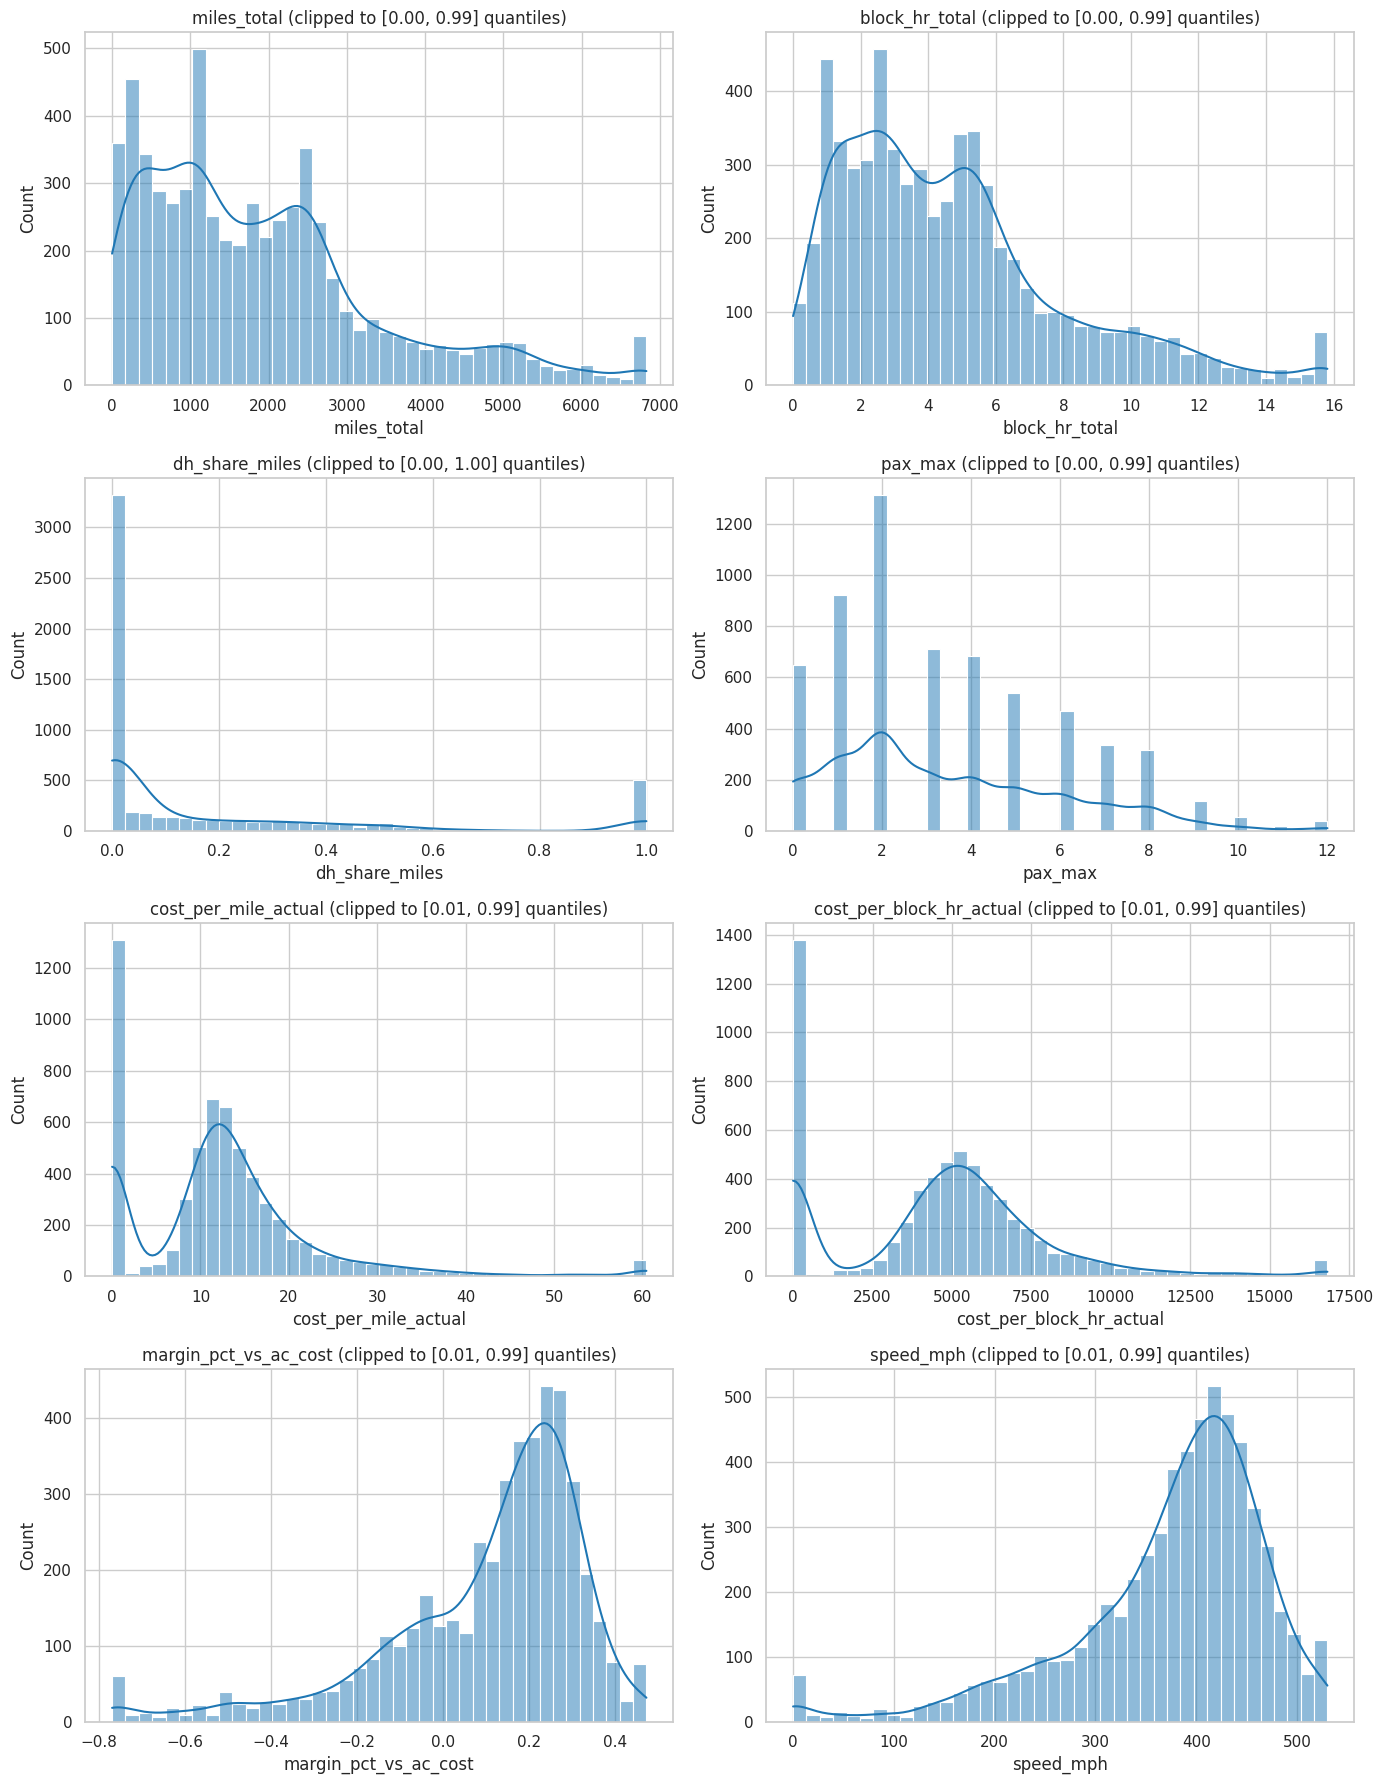

In [42]:

# --- Distribution plots (winsorized view for readability, plus raw outlier counts) ---
plot_specs = [
    ('miles_total', (0, 0.99)),
    ('block_hr_total', (0, 0.99)),
    ('dh_share_miles', (0, 1.0)),
    ('pax_max', (0, 0.995)),
    ('cost_per_mile_actual', (0.01, 0.99)),
    ('cost_per_block_hr_actual', (0.01, 0.99)),
    ('margin_pct_vs_ac_cost', (0.01, 0.99)),
    ('speed_mph', (0.01, 0.99)),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.ravel()

for ax, (col, (qlo, qhi)) in zip(axes, plot_specs):
    s = trip[col].dropna()
    lo = s.quantile(qlo) if qlo > 0 else s.min()
    hi = s.quantile(qhi)
    s_clip = s.clip(lower=lo, upper=hi)
    sns.histplot(s_clip, bins=40, kde=True, ax=ax, color='#1f77b4')
    ax.set_title(f"{col} (clipped to [{qlo:.2f}, {qhi:.2f}] quantiles)")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [43]:
# --- Categorical distributions (top levels) ---
for col in cat_cols:
    if col not in trip.columns:
        continue
    vc = trip[col].astype('string').fillna('NA').value_counts(dropna=False)
    print("\n" + "="*90)
    print(f"{col} (top 15 of {vc.shape[0]} levels)")
    display(vc.head(15).to_frame('count'))


Trip_Status (top 15 of 4 levels)


,count
Trip_Status,
Completed,4889
NA,1150
Scheduled,79
Cancelled,49



Quote_Status (top 15 of 7 levels)


,count
Quote_Status,
Invoiced - Ready to Export,3825
NA,1150
Scheduled,1016
Cancelled,131
Approved,20
Ready,15
Paid - Exported to Accounting,10



qTrip_type_code (top 15 of 8 levels)


...

,count
trip_purpose,
CHTR,1061
C0NS,903
JSDH,777
NA,696
CSNS,458
C0NB,451
XSDS,405
XSSS,246
X0DS,232



dep_month (top 15 of 6 levels)


,count
dep_month,
2016-06,1107
2016-05,1069
2016-03,1049
2016-01,1015
2016-04,999
2016-02,928



dep_dow (top 15 of 7 levels)


,count
dep_dow,
Friday,956
Thursday,929
Monday,905
Wednesday,875
Saturday,858
Tuesday,829
Sunday,815


In [44]:
# --- Identify operational anomalies using aviation-informed rules of thumb ---
# (1) zero miles but nonzero cost
anom1 = trip[(trip['miles_total']==0) & (trip['quote_total_cost']>0)].copy()
# (2) extremely high cost per mile (top 0.5%)
cpm = trip['cost_per_mile_actual'].replace([np.inf,-np.inf], np.nan)
th_cpm = cpm.quantile(0.995)
anom2 = trip[cpm > th_cpm].copy()
# (3) implausible speeds (e.g., > 650 mph) - jets can be ~450-520 mph cruise; >650 often indicates bad times
spd = trip['speed_mph'].replace([np.inf,-np.inf], np.nan)
anom3 = trip[spd > 650].copy()
# (4) margin pct outside [-1,1] already possible but extreme negatives suggest mismatched cost fields
mp = trip['margin_pct_vs_ac_cost']
anom4 = trip[mp < mp.quantile(0.01)].copy()

print("\nOperational anomaly counts")
print({
    'zero_miles_positive_cost': len(anom1),
    'top_0.5%_cost_per_mile': len(anom2),
    'speed_gt_650_mph': len(anom3),
    'bottom_1%_margin_pct': len(anom4),
})



Operational anomaly counts
{'zero_miles_positive_cost': 1, 'top_0.5%_cost_per_mile': 31, 'speed_gt_650_mph': 8, 'bottom_1%_margin_pct': 47}


In [45]:
cols_show = ['Trip_Number','dep_dt_min','arr_dt_max','n_legs','miles_total','block_hr_total','speed_mph','dh_share_miles',
             'quote_total_cost','ac_cost_total','cost_per_mile_actual','cost_per_block_hr_actual','margin_pct_vs_ac_cost',
             'Trip_Status','Quote_Status','qRate_Type_Code','Quoted_For_Company','Quoted_Route']

for title, df_ex in [
    ('Zero miles but positive cost (sample)', anom1),
    ('Very high cost per mile (sample)', anom2),
    ('Implausible speed > 650 mph (sample)', anom3),
    ('Very negative margin pct (sample)', anom4),
]:
    print("\n" + "-"*90)
    print(title)
    display(df_ex[ [c for c in cols_show if c in df_ex.columns] ].head(10))


------------------------------------------------------------------------------------------
Zero miles but positive cost (sample)


,Trip_Number,dep_dt_min,arr_dt_max,n_legs,miles_total,block_hr_total,speed_mph,dh_share_miles,quote_total_cost,ac_cost_total,cost_per_mile_actual,cost_per_block_hr_actual,margin_pct_vs_ac_cost,Trip_Status,Quote_Status,qRate_Type_Code,Quoted_For_Company,Quoted_Route
374,174003,2016-01-01 01:05:00,2016-01-01 01:05:00,1,0,0.0,NaN,NaN,25000.0,40150.0,NaN,NaN,-0.606,NaN,NaN,NaN,NaN,NaN



------------------------------------------------------------------------------------------
Very high cost per mile (sample)


,Trip_Number,dep_dt_min,arr_dt_max,n_legs,miles_total,block_hr_total,speed_mph,dh_share_miles,quote_total_cost,ac_cost_total,cost_per_mile_actual,cost_per_block_hr_actual,margin_pct_vs_ac_cost,Trip_Status,Quote_Status,qRate_Type_Code,Quoted_For_Company,Quoted_Route
246,173346,2016-01-03 17:00:00,2016-01-03 19:36:00,2,271,2.116667,128.031496,0.0,24495.81,22176.82,90.390443,11572.823622,0.094669,NaN,NaN,NaN,NaN,NaN
290,173669,2016-01-12 15:50:00,2016-01-12 16:59:00,1,190,1.150000,165.217391,0.0,29000.50,23100.00,152.634211,25217.826087,0.203462,NaN,NaN,NaN,NaN,NaN
341,173906,2016-01-04 01:07:00,2016-01-04 02:09:00,1,337,1.033333,326.129032,0.0,30469.13,26000.00,90.412849,29486.254839,0.146677,NaN,NaN,NaN,NaN,NaN
550,174540,2016-01-07 22:39:00,2016-01-07 22:45:00,1,9,0.100000,90.000000,0.0,2924.67,2055.18,324.963333,29246.700000,0.297295,Completed,Invoiced - Ready to Export,CHTR,"Carroll, Jason Eastwick",KJRB-KLGA
789,174913,2016-01-13 00:30:00,2016-01-14 19:00:00,5,910,4.400000,206.818182,0.0,78238.84,61625.00,85.976747,17781.554545,0.212348,Completed,Invoiced - Ready to Export,CHTR,Lone Star Funds,KTEB-KBWI KIAD-KTTN KTTN-KRIC KRIC-KRDU KRDU-KCAE
898,175097,2016-06-30 20:33:00,2016-06-30 20:53:00,1,30,0.333333,90.000000,1.0,34000.00,36450.00,1133.333333,102000.000000,-0.072059,Scheduled,Scheduled,XSSB,MacGregor & Mary Read Revocable Trust - PRF6,KOAK-KACK
1309,175754,2016-02-04 21:47:00,2016-02-04 23:14:00,1,300,1.450000,206.896552,1.0,29345.80,22276.67,97.819333,20238.482759,0.240891,Completed,Cancelled,C0NS,Anthony Diaco - PRF5,KTEB-KBLM KBLM-K36U
2363,177548,2016-03-05 21:43:00,2016-03-05 22:21:00,1,93,0.633333,146.842105,0.0,10700.00,9040.00,115.053763,16894.736842,0.155140,Completed,Invoiced - Ready to Export,CHTR,"Caesars Enterprise Services, LLC (RETAIL)",KMMU-KACY
2711,178093,2016-03-14 19:55:00,2016-03-14 21:02:00,1,246,1.116667,220.298507,1.0,43447.88,29870.38,176.617398,38908.549254,0.312501,Completed,Cancelled,C0NB,Magellan Jets,KDFW-KROA KROA-KSRQ KSRQ-KFLL KFLL-MDPP MDPP-KOPF
3418,179296,2016-04-04 01:59:00,2016-04-04 02:38:00,1,100,0.650000,153.846154,1.0,20000.00,48950.00,200.000000,30769.230769,-1.447500,Completed,Cancelled,XSDS,Gores Group,PHOG-KVNY



------------------------------------------------------------------------------------------
Implausible speed > 650 mph (sample)


,Trip_Number,dep_dt_min,arr_dt_max,n_legs,miles_total,block_hr_total,speed_mph,dh_share_miles,quote_total_cost,ac_cost_total,cost_per_mile_actual,cost_per_block_hr_actual,margin_pct_vs_ac_cost,Trip_Status,Quote_Status,qRate_Type_Code,Quoted_For_Company,Quoted_Route
343,173931,2016-01-27 22:05:00,2016-01-27 23:40:00,1,1085,1.583333,685.263158,0.0,19260.22,17600.00,17.751355,12164.349474,0.086199,NaN,NaN,NaN,NaN,NaN
625,174660,2016-04-04 23:40:00,2016-04-08 19:25:00,4,7678,10.500000,731.238095,0.0,140728.82,122920.14,18.328838,13402.744762,0.126546,Completed,Invoiced - Ready to Export,CHTR,Niraj Shah - ICONIQ PRF4,KBED-EDDB EDDB-EGKB EGKB-EINN EINN-KBED
858,175028,2016-02-14 16:23:00,2016-02-16 18:07:00,2,6396,8.950000,714.636872,0.0,143783.00,127500.00,22.480144,16065.139665,0.113247,NaN,NaN,NaN,NaN,NaN
1370,175863,2016-01-29 00:04:00,2016-01-29 03:03:00,1,1954,2.983333,654.972067,0.0,22037.00,18500.02,11.277892,7386.703911,0.160502,Completed,Invoiced - Ready to Export,CHTR,Polar Company,KMMU-KSLC
2459,177703,2016-06-04 19:46:00,2016-06-05 00:39:00,2,4663,4.233333,1101.496063,0.0,82526.31,73848.07,17.698115,19494.403937,0.105157,Completed,Invoiced - Ready to Export,CHTR,Leach Capital LLC - PRF6,KPBI-KMHT KMHT-LFPB
3518,179472,2016-04-10 22:10:00,2016-04-11 00:00:00,1,1856,1.833333,1012.363636,0.0,39500.00,35000.00,21.282328,21545.454545,0.113924,Completed,Invoiced - Ready to Export,CHTR,Philip Rivers - PRF5,KECP-KCRQ
5362,182581,2016-06-13 12:50:00,2016-06-13 13:10:00,1,236,0.333333,708.000000,0.0,22517.66,16500.00,95.413814,67552.980000,0.267242,Completed,Invoiced - Ready to Export,CHTR,"Kordestani, Omid",LFPB-EGGW
5788,183356,2016-06-15 05:40:00,2016-06-15 06:05:00,1,331,0.416667,794.400000,0.0,7095.11,6000.00,21.435378,17028.264000,0.154347,Completed,Invoiced - Ready to Export,CHTR,"Coon, Jonathan Craig",KSMO-KSFO



------------------------------------------------------------------------------------------
Very negative margin pct (sample)


,Trip_Number,dep_dt_min,arr_dt_max,n_legs,miles_total,block_hr_total,speed_mph,dh_share_miles,quote_total_cost,ac_cost_total,cost_per_mile_actual,cost_per_block_hr_actual,margin_pct_vs_ac_cost,Trip_Status,Quote_Status,qRate_Type_Code,Quoted_For_Company,Quoted_Route
103,171192,2016-01-02 20:06:00,2016-01-03 16:54:00,2,1276,3.800000,335.789474,0.063480,16156.43,29650.0,12.661779,4251.692105,-0.835183,NaN,NaN,NaN,NaN,NaN
270,173531,2016-01-10 18:53:00,2016-01-11 21:45:00,3,2245,5.700000,393.859649,0.235635,18000.00,33000.0,8.017817,3157.894737,-0.833333,NaN,NaN,NaN,NaN,NaN
283,173630,2016-01-02 17:24:00,2016-01-02 19:36:00,1,887,2.200000,403.181818,0.000000,11605.08,22350.0,13.083517,5275.036364,-0.925881,NaN,NaN,NaN,NaN,NaN
584,174594,2016-01-09 18:47:00,2016-01-11 17:18:00,2,2196,5.466667,401.707317,0.000000,22000.00,44000.0,10.018215,4024.390244,-1.000000,Completed,Invoiced - Ready to Export,XSDS,Unity Jets,KMIA-KTEB KTEB-KMIA
707,174772,2016-01-17 15:54:00,2016-01-17 19:51:00,2,1268,3.200000,396.250000,0.041009,13000.00,26400.0,10.252366,4062.500000,-1.030769,Completed,Invoiced - Ready to Export,XSDS,Jet Linx Aviation,KSNA-KDAL
758,174861,2016-01-12 20:05:00,2016-01-13 02:45:00,2,1044,2.833333,368.470588,0.091954,12500.00,24750.0,11.973180,4411.764706,-0.980000,Completed,Invoiced - Ready to Export,XSDS,Unity Jets,KMIA-KLUK
921,175136,2016-01-16 17:36:00,2016-01-16 23:10:00,2,2298,4.800000,478.750000,0.158834,19500.00,35200.0,8.485640,4062.500000,-0.805128,Completed,Invoiced - Ready to Export,XSDS,Jets.com,KTUS-KIAD
1237,175658,2016-03-19 17:20:00,2016-03-19 21:16:00,1,1704,3.933333,433.220339,0.000000,14113.40,26400.0,8.282512,3588.152542,-0.870563,Completed,Invoiced - Ready to Export,XSDS,"Costa, Jose",KOPF-KAPA
1271,175706,2016-01-30 20:56:00,2016-01-31 20:07:00,3,1808,5.200000,347.692308,0.059181,19000.00,38500.0,10.508850,3653.846154,-1.026316,Completed,Cancelled,XSDS,"Pantzer, Jordan Matthew",TNCM-KTEB
1282,175720,2016-01-26 19:00:00,2016-01-27 00:15:00,1,2333,5.250000,444.380952,0.000000,9000.00,35200.0,3.857694,1714.285714,-2.911111,Completed,Invoiced - Ready to Export,XSDS,Jet Demands,KPBI-KSMO


In [46]:
trip_cln = trip.copy()

# Treat known problematic/undefined derived rates as NaN
trip_cln.loc[trip_cln['miles_total'] <= 0, ['cost_per_mile_actual']] = np.nan
trip_cln.loc[trip_cln['block_hr_total'] <= 0, ['cost_per_block_hr_actual', 'speed_mph']] = np.nan

# Remove obviously invalid financials for analysis of pricing (keep a copy for audit)
# Negative quote_total_cost is almost certainly reversal/credit; exclude for pricing model/EDA
trip_cln = trip_cln[trip_cln['quote_total_cost'] >= 0].copy()

# Focus on completed/invoiced trips when studying realized pricing vs ops drivers
# (Quotes table join is missing for ~18.6% of trips; completed legs exist regardless.)
trip_realized = trip_cln[trip_cln['Quote_Status'].fillna('NA').isin(['Invoiced - Ready to Export','Paid - Exported to Accounting'])].copy()

print('All trips:', trip.shape)
print('After nonnegative quote_total_cost:', trip_cln.shape)
print('Realized (invoiced/paid):', trip_realized.shape)


All trips: (6167, 45)
After nonnegative quote_total_cost: (6166, 45)
Realized (invoiced/paid): (3835, 45)


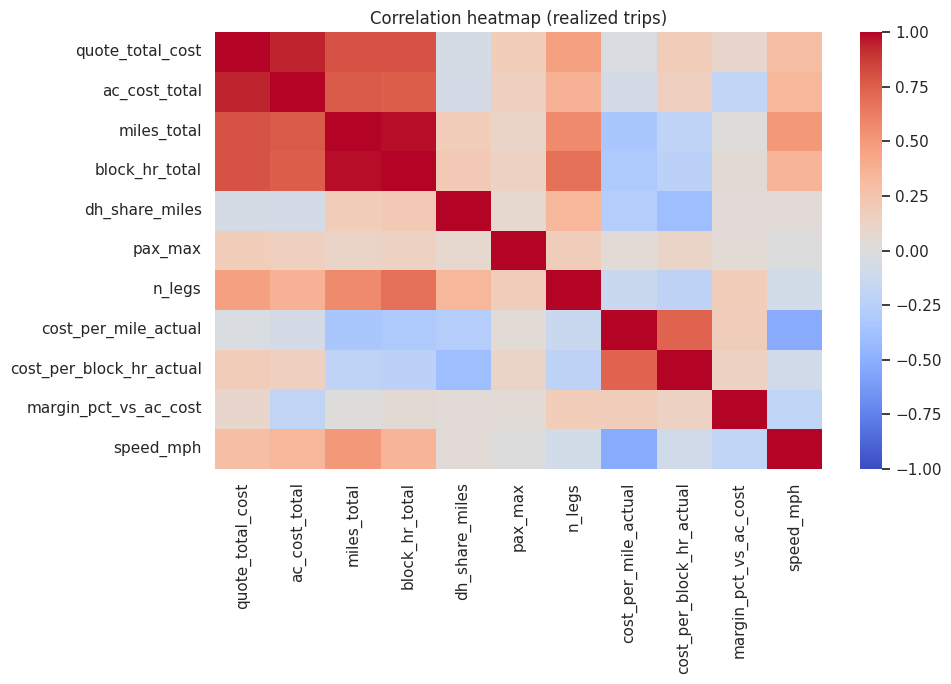

In [47]:
num_for_corr = [
    'quote_total_cost','ac_cost_total','miles_total','block_hr_total','dh_share_miles','pax_max','n_legs',
    'cost_per_mile_actual','cost_per_block_hr_actual','margin_pct_vs_ac_cost','speed_mph'
]

corr = trip_realized[num_for_corr].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation heatmap (realized trips)')
plt.tight_layout()
plt.show()


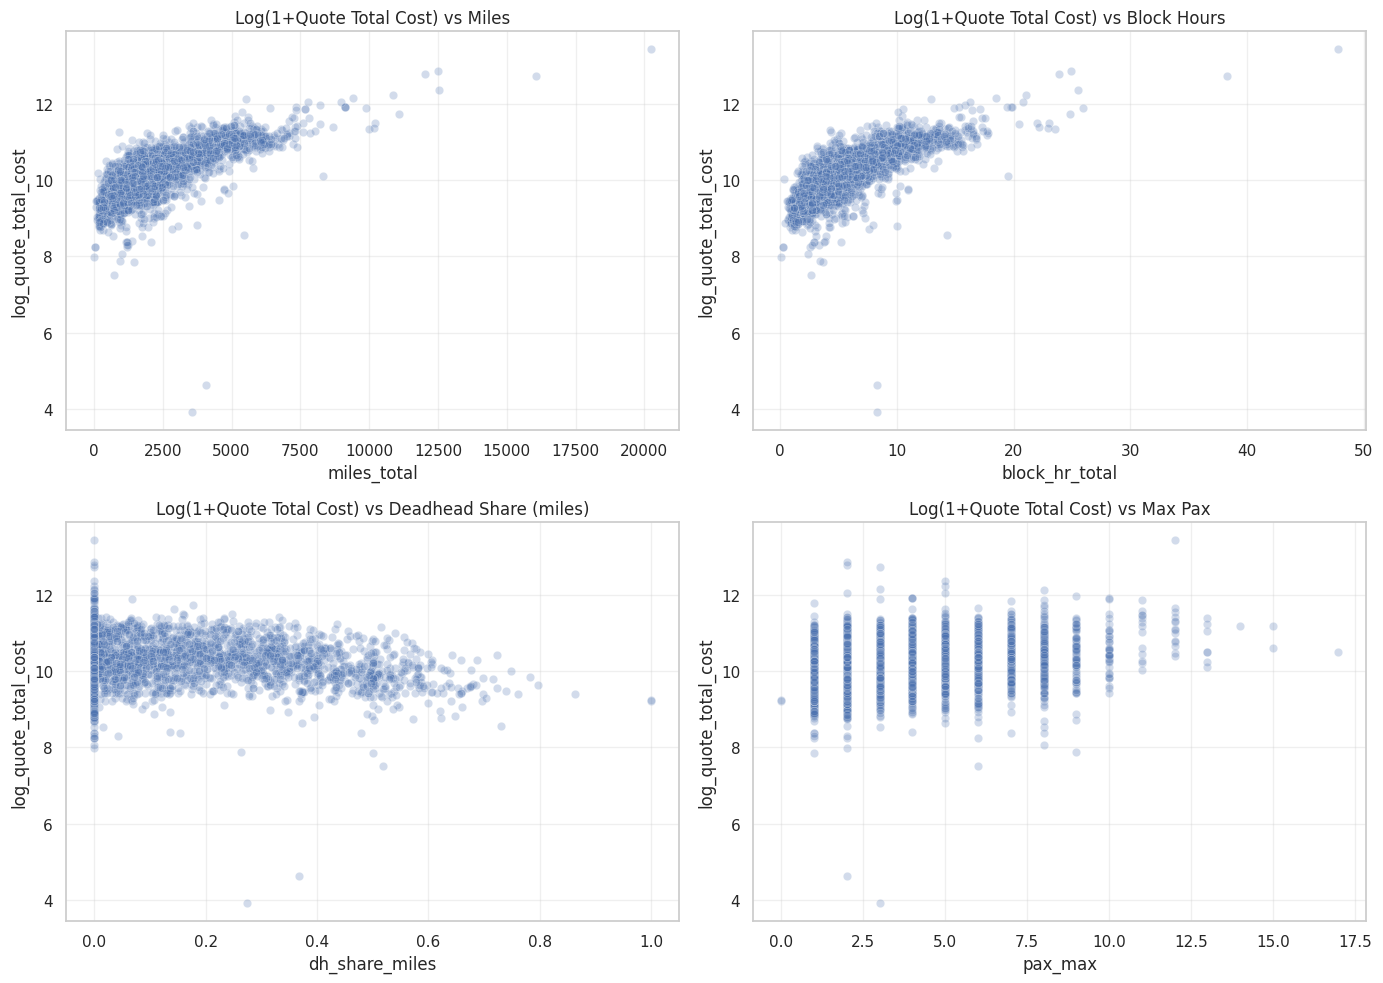

In [48]:
# --- Key bivariate plots: price vs operational drivers ---
# Use log scale for cost because of heavy right tail
plot_df = trip_realized.copy()
plot_df['log_quote_total_cost'] = np.log1p(plot_df['quote_total_cost'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=plot_df, x='miles_total', y='log_quote_total_cost', alpha=0.25, ax=axes[0,0])
axes[0,0].set_title('Log(1+Quote Total Cost) vs Miles')

sns.scatterplot(data=plot_df, x='block_hr_total', y='log_quote_total_cost', alpha=0.25, ax=axes[0,1])
axes[0,1].set_title('Log(1+Quote Total Cost) vs Block Hours')

sns.scatterplot(data=plot_df, x='dh_share_miles', y='log_quote_total_cost', alpha=0.25, ax=axes[1,0])
axes[1,0].set_title('Log(1+Quote Total Cost) vs Deadhead Share (miles)')

sns.scatterplot(data=plot_df, x='pax_max', y='log_quote_total_cost', alpha=0.25, ax=axes[1,1])
axes[1,1].set_title('Log(1+Quote Total Cost) vs Max Pax')

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


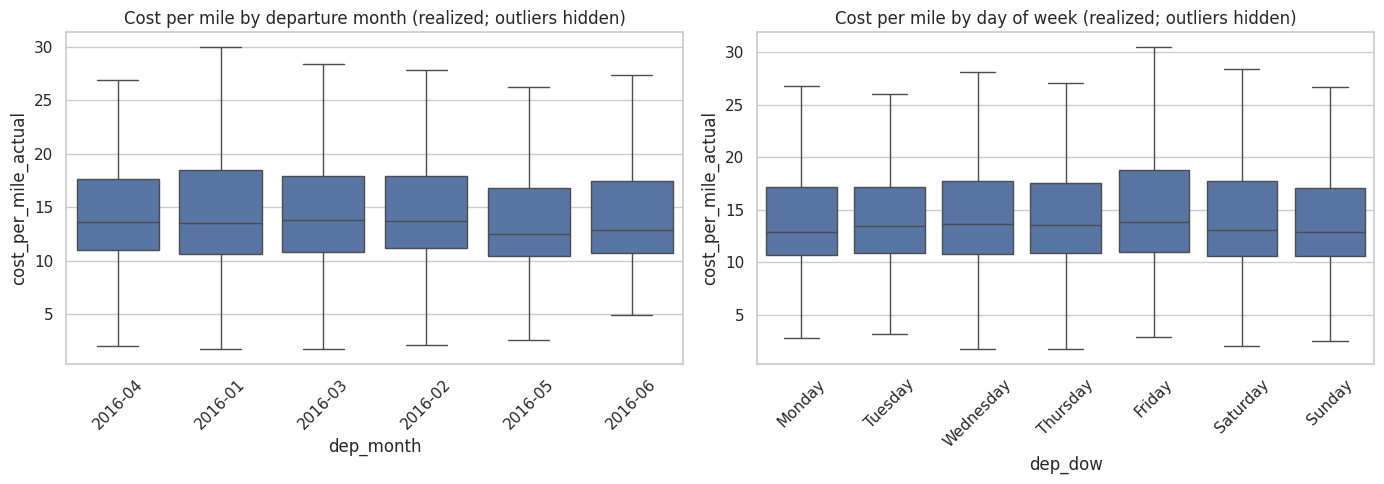

In [49]:
# --- Seasonality / weekday effects on unit economics (toggle candidates) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x='dep_month', y='cost_per_mile_actual', ax=axes[0], showfliers=False)
axes[0].set_title('Cost per mile by departure month (realized; outliers hidden)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=plot_df, x='dep_dow', y='cost_per_mile_actual', ax=axes[1], showfliers=False,
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
axes[1].set_title('Cost per mile by day of week (realized; outliers hidden)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


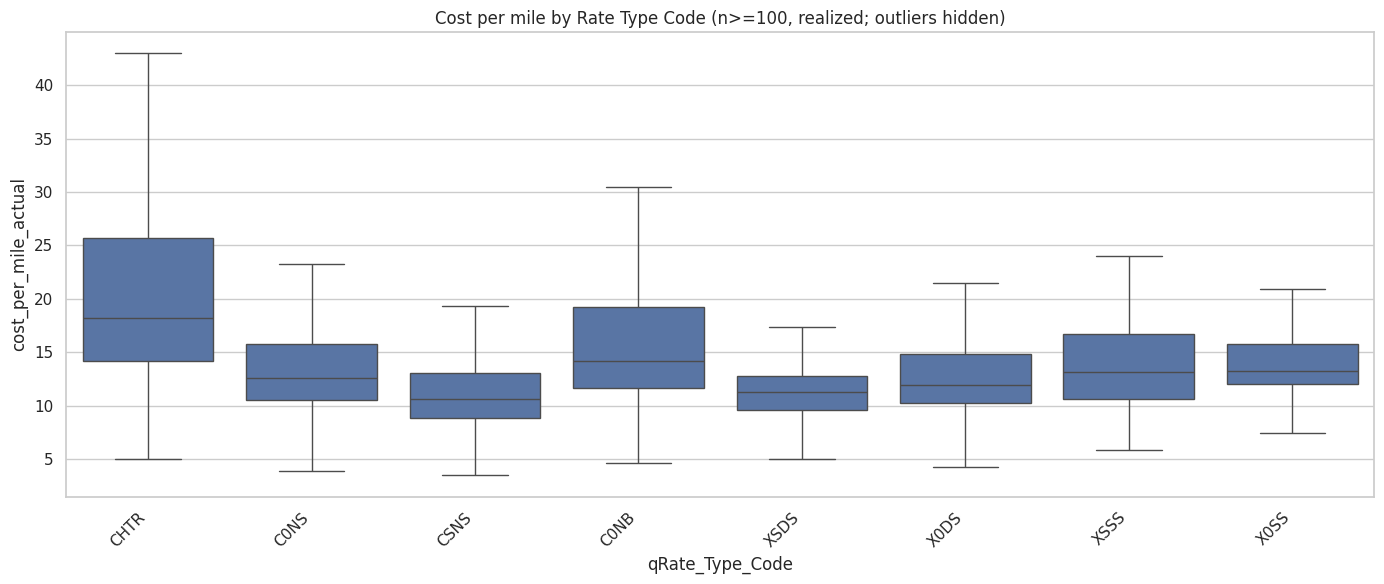

In [50]:
# --- Rate code / trip type effects (toggle candidates) ---
# Keep only reasonably frequent categories for readability
min_n = 100
rate_counts = plot_df['qRate_Type_Code'].astype('string').fillna('NA').value_counts()
rate_keep = rate_counts[rate_counts >= min_n].index.tolist()
plot_rate = plot_df[plot_df['qRate_Type_Code'].astype('string').fillna('NA').isin(rate_keep)].copy()
plot_rate['qRate_Type_Code'] = plot_rate['qRate_Type_Code'].astype('string').fillna('NA')

plt.figure(figsize=(14, 6))
order = plot_rate['qRate_Type_Code'].value_counts().index
sns.boxplot(data=plot_rate, x='qRate_Type_Code', y='cost_per_mile_actual', showfliers=False, order=order)
plt.title(f'Cost per mile by Rate Type Code (n>={min_n}, realized; outliers hidden)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [51]:
# Quick table: median unit economics by rate code (interpretable for pricing toggles)
rate_summary = (
    plot_rate.groupby('qRate_Type_Code')
    .agg(
        n=('Trip_Number','size'),
        med_cpm=('cost_per_mile_actual','median'),
        med_cph=('cost_per_block_hr_actual','median'),
        med_miles=('miles_total','median'),
        med_block_hr=('block_hr_total','median'),
        med_dh_share=('dh_share_miles','median'),
        med_margin_pct=('margin_pct_vs_ac_cost','median')
    )
    .sort_values('n', ascending=False)
)

display(rate_summary.round(3))


,n,med_cpm,med_cph,med_miles,med_block_hr,med_dh_share,med_margin_pct
qRate_Type_Code,,,,,,,
CHTR,862,18.260,6353.234,1183.0,3.333,0.000,0.172
C0NS,778,12.625,5236.010,2299.0,5.467,0.079,0.279
CSNS,388,10.655,4486.136,2246.5,5.142,0.104,0.259
C0NB,377,14.216,5487.002,2286.0,5.650,0.102,0.260
XSDS,342,11.326,4798.644,2198.0,4.867,0.022,-0.247
X0DS,196,11.965,5371.892,2328.0,5.183,0.032,-0.124
XSSS,189,13.197,5749.586,2270.0,5.217,0.023,-0.031
X0SS,145,13.279,6138.514,2379.0,5.100,0.009,0.030


In [52]:
# %%geminicli_magic
# Help me understand the trip_cln dataframe.


In [53]:
# trip_cln.head()
# trip_cln.info()
# trip_cln.describe()
# trip_cln.isnull().sum()
# trip_cln.columns

# part 2

In [54]:
# Aircraft Fleet Utilization Analysis
# Analyze how the available fleet is being utilized over time -> This can be critical for capacity planning and revenue optimization

# Add derived fields for utilization analysis
avail_ts = avail.copy()
avail_ts['year_month'] = avail_ts['date'].dt.to_period('M').astype('string')
avail_ts['day_of_week'] = avail_ts['date'].dt.day_name()
avail_ts['total_fleet'] = avail_ts['sold'] + avail_ts['available']
avail_ts['utilization_rate'] = avail_ts['sold'] / avail_ts['total_fleet']

# Monthly aggregation
monthly_util = (
    avail_ts.groupby('year_month')
    .agg(
        avg_sold=('sold', 'mean'),
        avg_available=('available', 'mean'),
        avg_total_fleet=('total_fleet', 'mean'),
        avg_utilization=('utilization_rate', 'mean'),
        days=('date', 'count')
    )
    .reset_index()
)

print('Monthly Fleet Utilization Summary:')
display(monthly_util.round(2))

Monthly Fleet Utilization Summary:


,year_month,avg_sold,avg_available,avg_total_fleet,avg_utilization,days
0,2015-01,23.65,3.05,26.70,0.88,20
1,2015-02,25.64,1.86,27.50,0.93,28
2,2015-03,25.10,1.52,26.61,0.94,31
3,2015-04,26.63,2.00,28.63,0.93,30
4,2015-05,25.03,2.39,27.42,0.91,31
5,2015-06,24.83,1.37,26.20,0.94,30
6,2015-07,25.23,1.74,26.97,0.93,31
7,2015-08,24.65,2.39,27.03,0.91,31
8,2015-09,24.53,2.13,26.67,0.92,30
9,2015-10,25.23,1.90,27.13,0.93,31


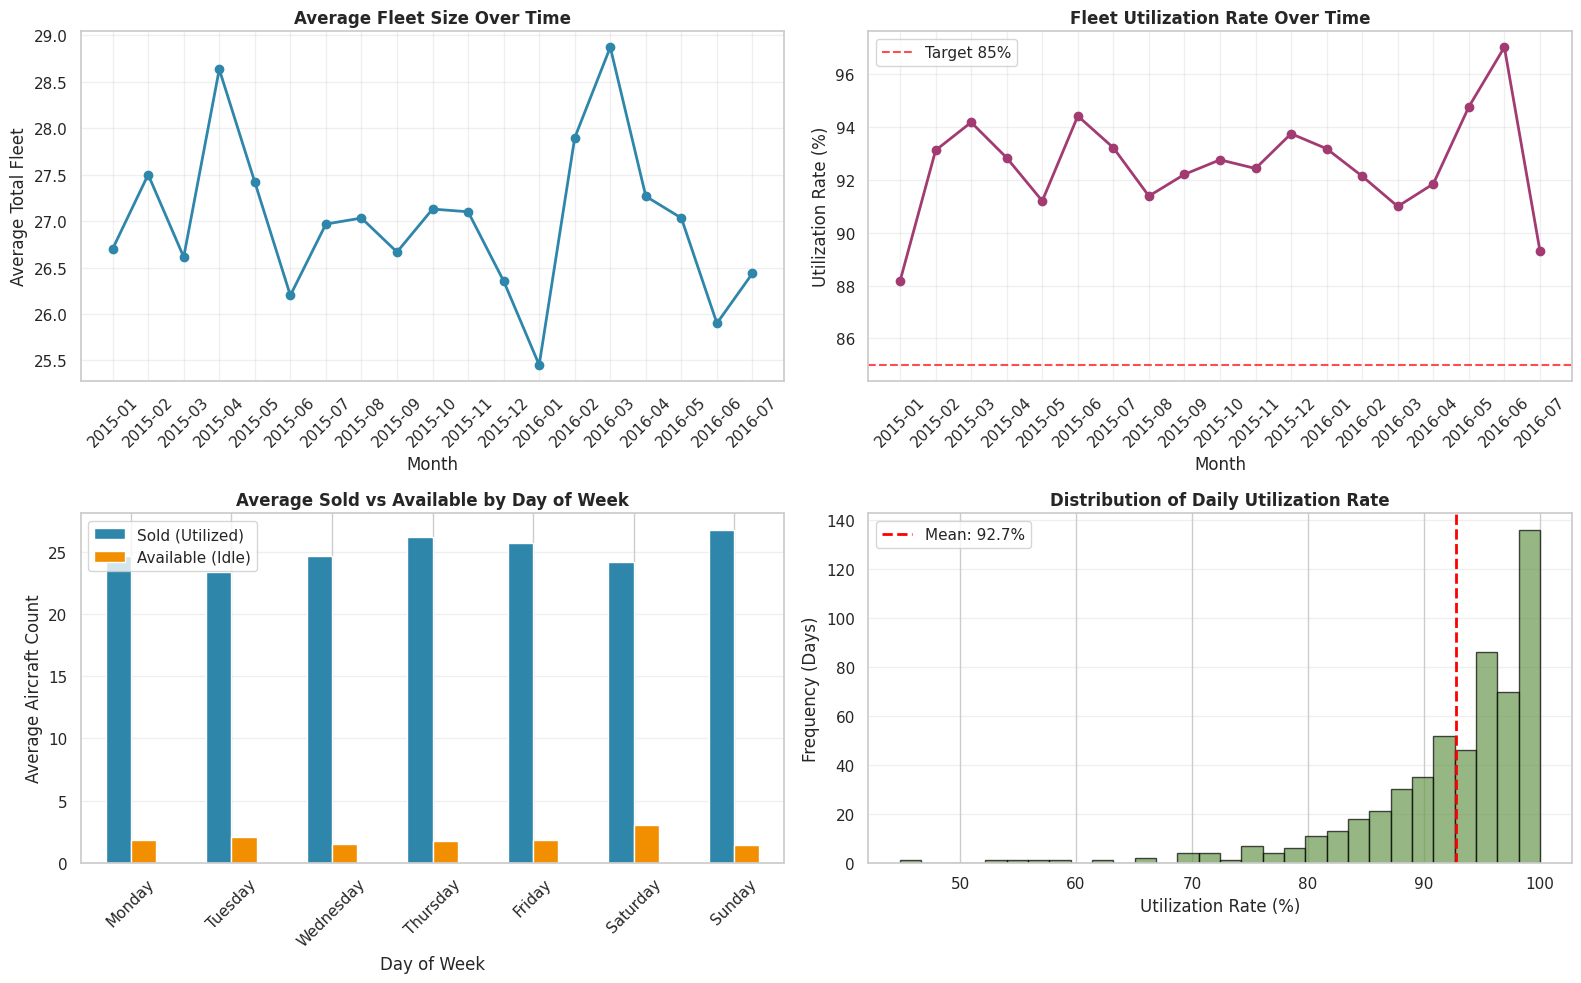

In [55]:
# Visualize utilization trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Fleet size over time
axes[0,0].plot(monthly_util['year_month'], monthly_util['avg_total_fleet'], marker='o', linewidth=2, color='#2E86AB')
axes[0,0].set_title('Average Fleet Size Over Time', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Average Total Fleet')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Utilization rate over time
axes[0,1].plot(monthly_util['year_month'], monthly_util['avg_utilization']*100, marker='o', linewidth=2, color='#A23B72')
axes[0,1].axhline(y=85, color='red', linestyle='--', label='Target 85%', alpha=0.7)
axes[0,1].set_title('Fleet Utilization Rate Over Time', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Utilization Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Sold vs Available by day of week
dow_util = avail_ts.groupby('day_of_week').agg({'sold': 'mean', 'available': 'mean'}).reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
dow_util.plot(kind='bar', ax=axes[1,0], color=['#2E86AB', '#F18F01'])
axes[1,0].set_title('Average Sold vs Available by Day of Week', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Day of Week')
axes[1,0].set_ylabel('Average Aircraft Count')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Sold (Utilized)', 'Available (Idle)'])
axes[1,0].grid(True, alpha=0.3, axis='y')

# 4. Distribution of utilization rate
axes[1,1].hist(avail_ts['utilization_rate']*100, bins=30, color='#6A994E', edgecolor='black', alpha=0.7)
axes[1,1].axvline(x=avail_ts['utilization_rate'].mean()*100, color='red', linestyle='--', linewidth=2, label=f"Mean: {avail_ts['utilization_rate'].mean()*100:.1f}%")
axes[1,1].set_title('Distribution of Daily Utilization Rate', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Utilization Rate (%)')
axes[1,1].set_ylabel('Frequency (Days)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [56]:
# Key insights
print('\n' + '='*80)
print('KEY UTILIZATION INSIGHTS:')
print('='*80)
print(f"Overall average utilization: {avail_ts['utilization_rate'].mean()*100:.1f}%")
print(f"Peak utilization month: {monthly_util.loc[monthly_util['avg_utilization'].idxmax(), 'year_month']} ({monthly_util['avg_utilization'].max()*100:.1f}%)")
print(f"Lowest utilization month: {monthly_util.loc[monthly_util['avg_utilization'].idxmin(), 'year_month']} ({monthly_util['avg_utilization'].min()*100:.1f}%)")
print(f"Average fleet size: {avail_ts['total_fleet'].mean():.1f} aircraft")
print(f"Days with 100% utilization: {(avail_ts['utilization_rate']==1.0).sum()} ({(avail_ts['utilization_rate']==1.0).sum()/len(avail_ts)*100:.1f}%)")
print(f"Days with <70% utilization: {(avail_ts['utilization_rate']<0.7).sum()} ({(avail_ts['utilization_rate']<0.7).sum()/len(avail_ts)*100:.1f}%)")


KEY UTILIZATION INSIGHTS:
Overall average utilization: 92.7%
Peak utilization month: 2016-06 (97.0%)
Lowest utilization month: 2015-01 (88.2%)
Average fleet size: 27.0 aircraft
Days with 100% utilization: 136 (24.6%)
Days with <70% utilization: 10 (1.8%)


In [57]:
# Route Network Analysis
# Analyze route profitability, key city pairs, and network structure -> help identify which routes are most valuable and where to focus capacity

# Extract origin-destination pairs from realized trips
route_analysis = trip_realized.copy()

# Parse route pairs (first and last airport from quoted route)
def extract_route_pair(route_str):
    if pd.isna(route_str) or route_str == '':
        return None
    parts = str(route_str).split()
    if len(parts) == 0:
        return None
    # Get first leg origin and last leg destination
    first_leg = parts[0].split('-')
    last_leg = parts[-1].split('-')
    if len(first_leg) >= 2 and len(last_leg) >= 2:
        origin = first_leg[0]
        destination = last_leg[-1]
        return f"{origin}-{destination}"
    return None

route_analysis['route_pair'] = route_analysis['Quoted_Route'].apply(extract_route_pair)

# Aggregate by route pair
route_metrics = (
    route_analysis[route_analysis['route_pair'].notna()]
    .groupby('route_pair')
    .agg(
        n_trips=('Trip_Number', 'size'),
        avg_miles=('miles_total', 'mean'),
        avg_cost=('quote_total_cost', 'mean'),
        avg_margin_pct=('margin_pct_vs_ac_cost', 'mean'),
        avg_cpm=('cost_per_mile_actual', 'mean'),
        avg_pax=('pax_max', 'mean'),
        avg_dh_share=('dh_share_miles', 'mean'),
        total_revenue=('quote_total_cost', 'sum')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print(f'Total unique route pairs: {len(route_metrics)}')
print(f'Routes with 10+ trips: {(route_metrics["n_trips"] >= 10).sum()}')

Total unique route pairs: 1862
Routes with 10+ trips: 36


In [58]:
# Focus on statistically significant routes (10+ trips)
route_metrics_sig = route_metrics[route_metrics['n_trips'] >= 10].copy()

print('\n' + '='*80)
print('TOP 10 ROUTES BY REVENUE:')
print('='*80)
display(route_metrics_sig.head(10).round(2))


TOP 10 ROUTES BY REVENUE:


,route_pair,n_trips,avg_miles,avg_cost,avg_margin_pct,avg_cpm,avg_pax,avg_dh_share,total_revenue
1626,KTEB-KTEB,194,2839.91,38143.62,0.18,15.86,4.51,0.08,7399862.33
1423,KSJC-KSJC,113,3496.83,54915.20,0.18,18.36,3.82,0.10,6205417.04
1769,KVNY-KVNY,88,3042.49,39696.64,0.21,16.63,4.20,0.12,3493304.11
591,KHPN-KHPN,82,2652.80,37173.78,0.15,16.28,3.73,0.06,3048250.04
958,KOAK-KOAK,56,3283.77,46439.84,0.15,18.41,4.59,0.12,2600630.80
160,KBED-KBED,50,3331.94,42165.05,0.20,15.82,4.08,0.18,2108252.59
1116,KPBI-KPBI,49,2997.08,41827.67,0.16,15.40,2.92,0.13,2049555.92
374,KDAL-KDAL,42,2790.33,35605.74,0.18,14.69,4.88,0.20,1495440.91
1384,KSFO-KSFO,37,2818.27,39319.38,0.25,18.69,3.62,0.09,1454817.06
1016,KOPF-KOPF,25,3547.96,47927.61,0.20,14.54,4.36,0.12,1198190.13


In [59]:
# Identify most profitable routes (high margin, high volume)
profitable_routes = route_metrics_sig[
    (route_metrics_sig['avg_margin_pct'] > 0.25) &
    (route_metrics_sig['n_trips'] >= 8)
].sort_values('total_revenue', ascending=False).head(10)

print('\n' + '='*80)
print('MOST PROFITABLE ROUTES (>25% margin, 8+ trips):')
print('='*80)
display(profitable_routes.round(2))


MOST PROFITABLE ROUTES (>25% margin, 8+ trips):


,route_pair,n_trips,avg_miles,avg_cost,avg_margin_pct,avg_cpm,avg_pax,avg_dh_share,total_revenue
819,KMDW-KMDW,21,2641.90,38931.90,0.26,17.76,4.86,0.19,817569.97
1216,KPSP-KPSP,11,3889.18,44945.51,0.27,16.19,4.91,0.20,494400.57
354,KCRQ-KCRQ,11,2819.82,36555.19,0.26,16.50,4.64,0.07,402107.11


In [60]:
# Identify underperforming routes (negative margin, significant volume)
unprofitable_routes = route_metrics_sig[
    route_metrics_sig['avg_margin_pct'] < -0.1
].sort_values('total_revenue', ascending=False).head(10)

print('\n' + '='*80)
print('UNDERPERFORMING ROUTES (negative margin, high volume):')
print('='*80)
display(unprofitable_routes.round(2))


UNDERPERFORMING ROUTES (negative margin, high volume):


,route_pair,n_trips,avg_miles,avg_cost,avg_margin_pct,avg_cpm,avg_pax,avg_dh_share,total_revenue
1595,KTEB-KOPF,24,1433.00,18295.44,-0.14,13.99,3.08,0.02,439090.54
1038,KOPF-KTEB,24,1213.75,16321.71,-0.11,13.69,4.58,0.05,391721.14
175,KBED-KPBI,12,1768.08,18585.56,-0.14,10.97,2.67,0.18,223026.77


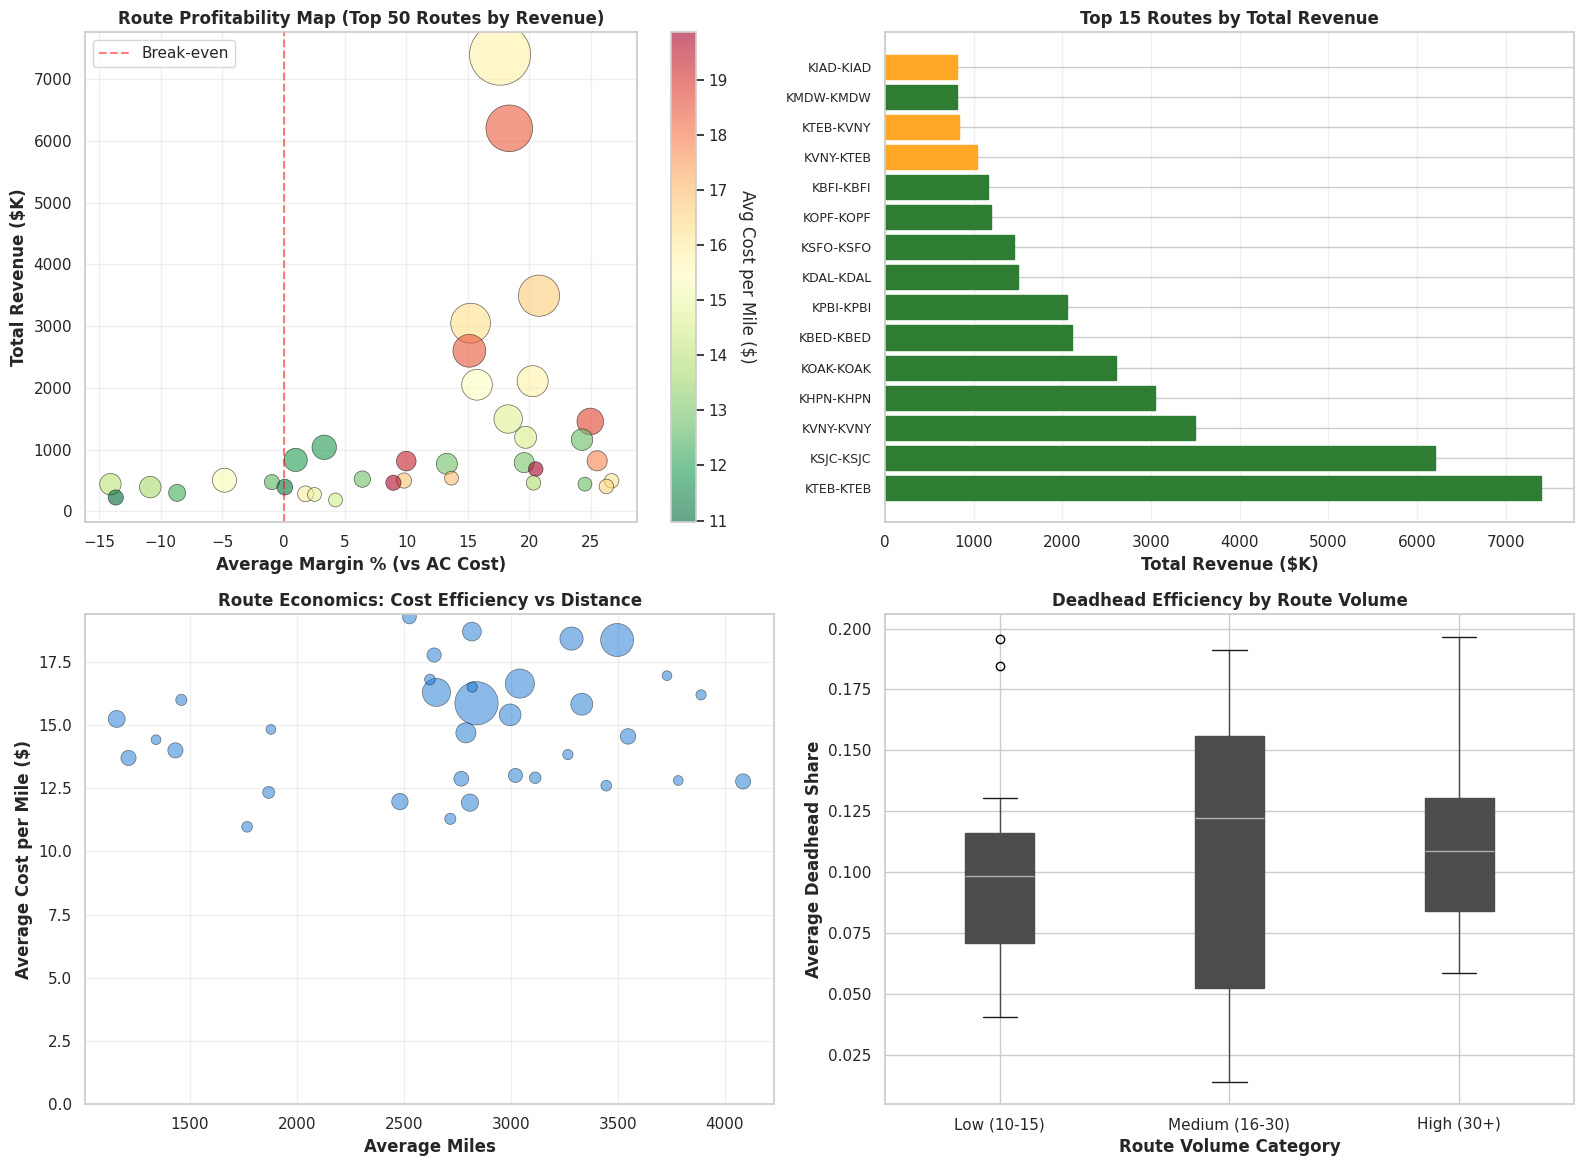

In [61]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Revenue vs Margin scatter for top routes
top_50 = route_metrics_sig.head(50)
scatter = axes[0,0].scatter(
    top_50['avg_margin_pct']*100,
    top_50['total_revenue']/1000,
    s=top_50['n_trips']*10,
    c=top_50['avg_cpm'],
    cmap='RdYlGn_r',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[0,0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Break-even')
axes[0,0].set_xlabel('Average Margin % (vs AC Cost)', fontweight='bold')
axes[0,0].set_ylabel('Total Revenue ($K)', fontweight='bold')
axes[0,0].set_title('Route Profitability Map (Top 50 Routes by Revenue)', fontsize=12, fontweight='bold')
axes[0,0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0,0])
cbar.set_label('Avg Cost per Mile ($)', rotation=270, labelpad=20)
axes[0,0].legend()

# 2. Top 15 routes by revenue
top_15_routes = route_metrics_sig.head(15)
bars = axes[0,1].barh(range(len(top_15_routes)), top_15_routes['total_revenue']/1000)
axes[0,1].set_yticks(range(len(top_15_routes)))
axes[0,1].set_yticklabels(top_15_routes['route_pair'], fontsize=9)
axes[0,1].set_xlabel('Total Revenue ($K)', fontweight='bold')
axes[0,1].set_title('Top 15 Routes by Total Revenue', fontsize=12, fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='x')
# Color bars by margin
for i, (idx, row) in enumerate(top_15_routes.iterrows()):
    if row['avg_margin_pct'] > 0.15:
        bars[i].set_color('#2E7D32')  # Green for profitable
    elif row['avg_margin_pct'] > 0:
        bars[i].set_color('#FFA726')  # Orange for low margin
    else:
        bars[i].set_color('#D32F2F')  # Red for negative margin

# 3. Cost per mile vs Distance for routes
axes[1,0].scatter(
    route_metrics_sig['avg_miles'],
    route_metrics_sig['avg_cpm'],
    s=route_metrics_sig['n_trips']*5,
    alpha=0.5,
    c='#1976D2',
    edgecolors='black',
    linewidth=0.5
)
axes[1,0].set_xlabel('Average Miles', fontweight='bold')
axes[1,0].set_ylabel('Average Cost per Mile ($)', fontweight='bold')
axes[1,0].set_title('Route Economics: Cost Efficiency vs Distance', fontsize=12, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_ylim(0, route_metrics_sig['avg_cpm'].quantile(0.95))

# 4. Deadhead share distribution by route volume
route_metrics_sig['volume_category'] = pd.cut(
    route_metrics_sig['n_trips'],
    bins=[0, 15, 30, 1000],
    labels=['Low (10-15)', 'Medium (16-30)', 'High (30+)']
)
route_metrics_sig.boxplot(
    column='avg_dh_share',
    by='volume_category',
    ax=axes[1,1],
    patch_artist=True
)
axes[1,1].set_xlabel('Route Volume Category', fontweight='bold')
axes[1,1].set_ylabel('Average Deadhead Share', fontweight='bold')
axes[1,1].set_title('Deadhead Efficiency by Route Volume', fontsize=12, fontweight='bold')
axes[1,1].get_figure().suptitle('')  # Remove auto title
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [62]:
print('\n' + '='*80)
print('KEY ROUTE INSIGHTS:')
print('='*80)

print(f"Most profitable route: {profitable_routes.iloc[0]['route_pair']} (margin: {profitable_routes.iloc[0]['avg_margin_pct']*100:.1f}%)")
print(f"Highest revenue route: {route_metrics_sig.iloc[0]['route_pair']} (${route_metrics_sig.iloc[0]['total_revenue']/1000:.0f}K)")
print(f"Average cost per mile across all routes: ${route_metrics_sig['avg_cpm'].mean():.2f}")
print(f"Routes with negative margins: {(route_metrics_sig['avg_margin_pct'] < 0).sum()} ({(route_metrics_sig['avg_margin_pct'] < 0).sum()/len(route_metrics_sig)*100:.1f}%)")


KEY ROUTE INSIGHTS:
Most profitable route: KMDW-KMDW (margin: 25.5%)
Highest revenue route: KTEB-KTEB ($7400K)
Average cost per mile across all routes: $15.14
Routes with negative margins: 6 (16.7%)


In [63]:
# Customer Segmentation & Value Analysis
# Analyze customer booking patterns, profitability, and identify high-value segments -> helps with customer retention, pricing strategy, and sales focus

customer_analysis = trip_realized.copy()

# Aggregate by customer (Quoted_For_Company)
customer_metrics = (
    customer_analysis[customer_analysis['Quoted_For_Company'].notna()]
    .groupby('Quoted_For_Company')
    .agg(
        n_trips=('Trip_Number', 'size'),
        total_revenue=('quote_total_cost', 'sum'),
        avg_trip_cost=('quote_total_cost', 'mean'),
        avg_margin_pct=('margin_pct_vs_ac_cost', 'mean'),
        avg_miles=('miles_total', 'mean'),
        avg_pax=('pax_max', 'mean'),
        avg_dh_share=('dh_share_miles', 'mean'),
        total_miles=('miles_total', 'sum')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print(f'Total unique customers: {len(customer_metrics)}')
print(f'Customers with 10+ trips: {(customer_metrics["n_trips"] >= 10).sum()}')


Total unique customers: 1314
Customers with 10+ trips: 58


In [64]:
# Focus on significant customers (10+ trips)
customer_metrics_sig = customer_metrics[customer_metrics['n_trips'] >= 10].copy()

print('\n' + '='*80)
print('TOP 15 CUSTOMERS BY REVENUE:')
print('='*80)
display(customer_metrics_sig.head(15).round(2))


TOP 15 CUSTOMERS BY REVENUE:


,Quoted_For_Company,n_trips,total_revenue,avg_trip_cost,avg_margin_pct,avg_miles,avg_pax,avg_dh_share,total_miles
1059,Sentient Jet,149,3453868.84,23180.33,0.09,1837.61,4.74,0.19,273804
83,"Apple, Inc",27,2055750.08,76138.89,0.24,3568.44,3.89,0.06,96348
108,Bain Capital - PRF4,36,1533300.95,42591.69,0.22,2572.56,2.86,0.09,92612
1216,Unity Jets,68,1504179.23,22120.28,-0.23,2370.31,3.71,0.12,161181
738,Magellan Jets,60,1355812.95,22596.88,-0.06,2252.60,3.45,0.16,135156
601,Jet Demands,64,995273.53,15551.15,-0.36,1618.03,3.08,0.10,103554
1029,SAP,25,967726.79,38709.07,0.22,2771.16,2.76,0.08,69279
1085,SkyJet,29,958700.07,33058.62,-0.07,3046.83,4.24,0.13,88358
616,"JetSmarter, Inc.",35,932592.35,26645.50,-0.03,2336.00,6.00,0.08,81760
747,Margaritaville Holdings LLC - PRF4,23,878399.11,38191.27,0.28,2405.65,3.43,0.05,55330


In [65]:
# Identify high-value customers (high revenue + good margins)
high_value = customer_metrics_sig[
    (customer_metrics_sig['total_revenue'] > customer_metrics_sig['total_revenue'].quantile(0.75)) &
    (customer_metrics_sig['avg_margin_pct'] > 0.15)
].sort_values('total_revenue', ascending=False)

print('\n' + '='*80)
print('HIGH-VALUE CUSTOMERS (Top 25% revenue + >15% margin):')
print('='*80)
display(high_value.head(15).round(2))


HIGH-VALUE CUSTOMERS (Top 25% revenue + >15% margin):


,Quoted_For_Company,n_trips,total_revenue,avg_trip_cost,avg_margin_pct,avg_miles,avg_pax,avg_dh_share,total_miles
83,"Apple, Inc",27,2055750.08,76138.89,0.24,3568.44,3.89,0.06,96348
108,Bain Capital - PRF4,36,1533300.95,42591.69,0.22,2572.56,2.86,0.09,92612
1029,SAP,25,967726.79,38709.07,0.22,2771.16,2.76,0.08,69279
747,Margaritaville Holdings LLC - PRF4,23,878399.11,38191.27,0.28,2405.65,3.43,0.05,55330
722,Lone Star Funds,14,857347.83,61239.13,0.16,2892.79,4.14,0.07,40499
1264,West End Productions,15,785686.83,52379.12,0.30,4076.80,4.60,0.18,61152


In [66]:
# Identify most profitable customers (high margin, reasonable volume)
profitable_customers = customer_metrics_sig[
    (customer_metrics_sig['avg_margin_pct'] > 0.25) &
    (customer_metrics_sig['n_trips'] >= 10)
].sort_values('total_revenue', ascending=False).head(10)

print('\n' + '='*80)
print('MOST PROFITABLE CUSTOMERS (>25% margin, 10+ trips):')
print('='*80)
display(profitable_customers.round(2))


MOST PROFITABLE CUSTOMERS (>25% margin, 10+ trips):


,Quoted_For_Company,n_trips,total_revenue,avg_trip_cost,avg_margin_pct,avg_miles,avg_pax,avg_dh_share,total_miles
747,Margaritaville Holdings LLC - PRF4,23,878399.11,38191.27,0.28,2405.65,3.43,0.05,55330
1264,West End Productions,15,785686.83,52379.12,0.30,4076.80,4.60,0.18,61152
939,"Phish, Inc. - PRF2",22,611323.95,27787.45,0.26,1462.05,4.27,0.07,32165
201,Celanese International Corporation - PRF5,16,578723.80,36170.24,0.29,2293.25,2.12,0.20,36692
625,John A. Pritzker - PRF6,16,433826.35,27114.15,0.27,1363.31,2.31,0.10,21813
750,Mark Burnett Productions - PRF5,11,382699.81,34790.89,0.26,2223.18,4.73,0.24,24455
1261,Wellspring Capital Mgmt - Retail,12,243934.72,20327.89,0.28,931.08,4.50,0.00,11173


In [67]:
# Customer segmentation by trip type
trip_type_metrics = (
    customer_analysis.groupby('qTrip_type_code')
    .agg(
        n_trips=('Trip_Number', 'size'),
        total_revenue=('quote_total_cost', 'sum'),
        avg_cost=('quote_total_cost', 'mean'),
        avg_margin_pct=('margin_pct_vs_ac_cost', 'mean'),
        avg_miles=('miles_total', 'mean'),
        avg_pax=('pax_max', 'mean'),
        avg_dh_share=('dh_share_miles', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print('\n' + '='*80)
print('REVENUE & PROFITABILITY BY TRIP TYPE:')
print('='*80)
display(trip_type_metrics.round(2))


REVENUE & PROFITABILITY BY TRIP TYPE:


,qTrip_type_code,n_trips,total_revenue,avg_cost,avg_margin_pct,avg_miles,avg_pax,avg_dh_share
3,RETA,2916,98392031.82,33742.12,0.14,2406.19,3.78,0.11
5,WHSL,799,18032117.76,22568.36,-0.03,2148.58,3.82,0.16
1,ELAC,80,2971626.53,37145.33,0.09,2095.60,3.21,0.14
2,FXO,37,283347.28,7658.03,0.11,2480.92,4.86,0.14
4,TPGP,1,8648.00,8648.00,0.07,737.00,6.00,0.55
0,C2C,2,150.63,75.32,1.00,3826.00,2.50,0.32


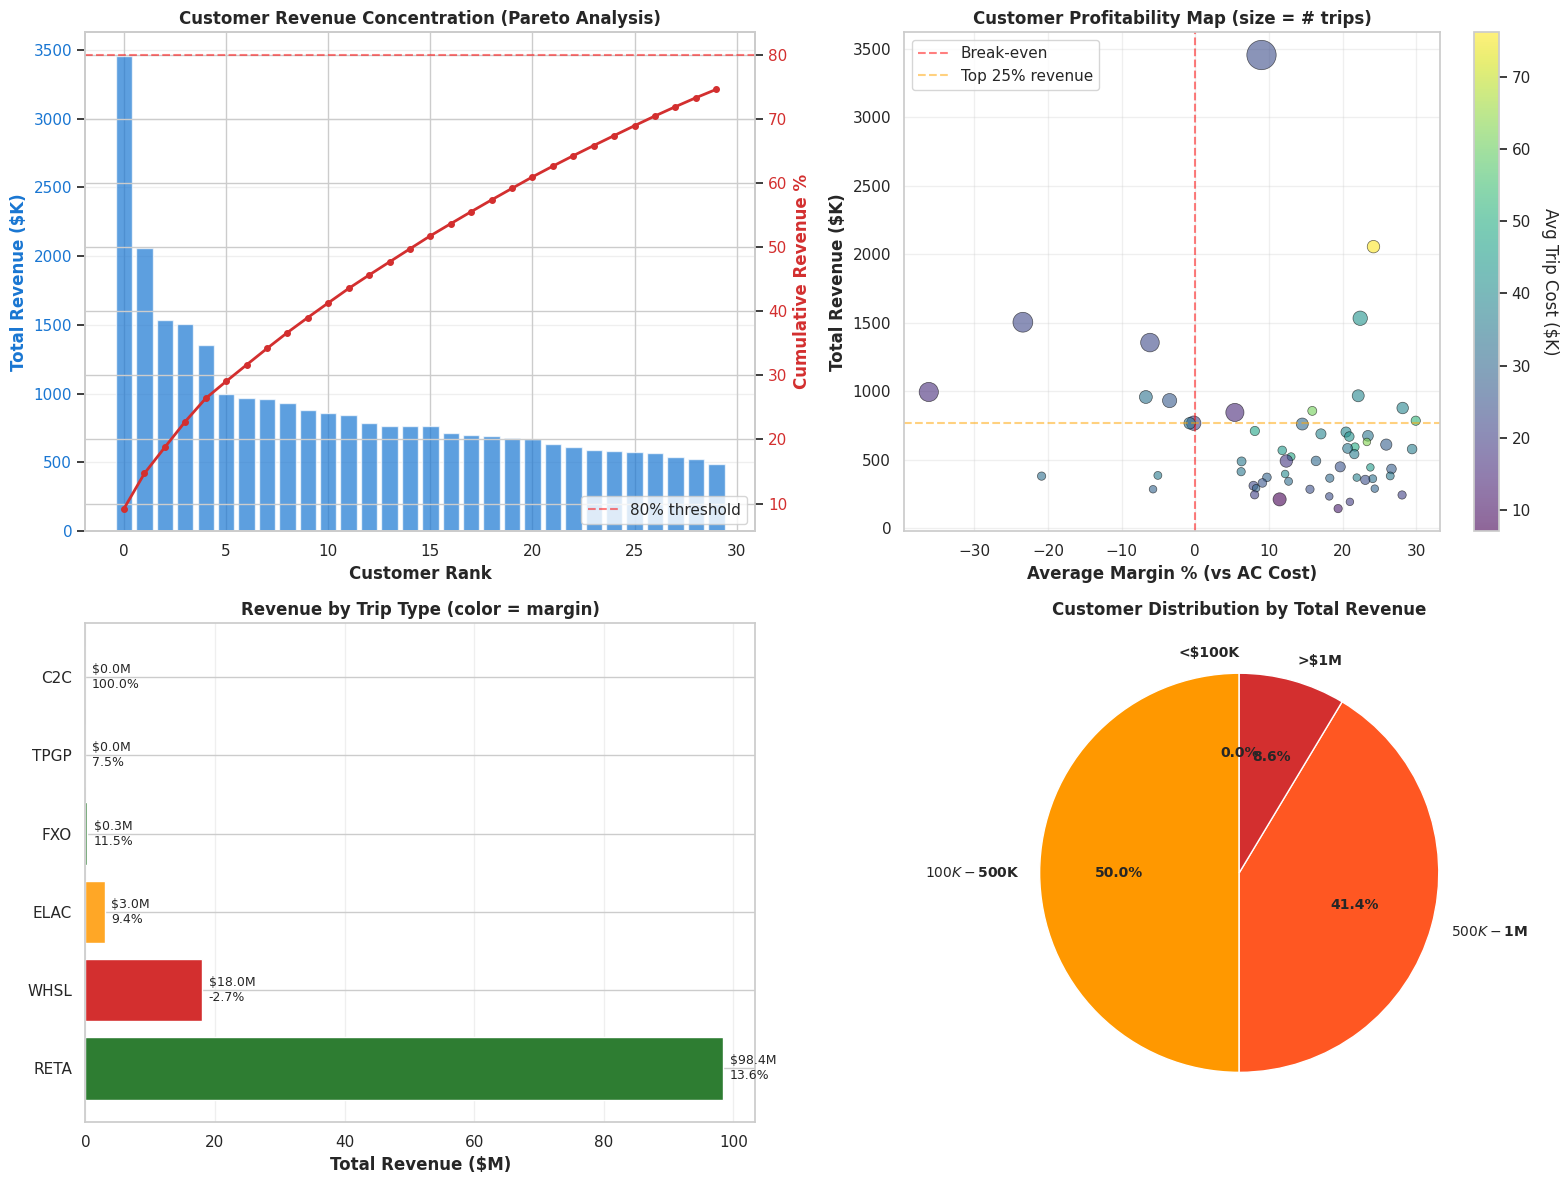

In [68]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Customer concentration - Pareto chart
top_30_customers = customer_metrics_sig.head(30)
cumulative_revenue = top_30_customers['total_revenue'].cumsum()
cumulative_pct = (cumulative_revenue / customer_metrics_sig['total_revenue'].sum()) * 100

ax1 = axes[0,0]
bars = ax1.bar(range(len(top_30_customers)), top_30_customers['total_revenue']/1000, color='#1976D2', alpha=0.7)
ax1_twin = ax1.twinx()
ax1_twin.plot(range(len(top_30_customers)), cumulative_pct, color='#D32F2F', marker='o', linewidth=2, markersize=4)
ax1_twin.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax1.set_xlabel('Customer Rank', fontweight='bold')
ax1.set_ylabel('Total Revenue ($K)', fontweight='bold', color='#1976D2')
ax1_twin.set_ylabel('Cumulative Revenue %', fontweight='bold', color='#D32F2F')
ax1.set_title('Customer Revenue Concentration (Pareto Analysis)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1976D2')
ax1_twin.tick_params(axis='y', labelcolor='#D32F2F')
ax1_twin.legend(loc='lower right')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Customer profitability scatter
scatter = axes[0,1].scatter(
    customer_metrics_sig['avg_margin_pct']*100,
    customer_metrics_sig['total_revenue']/1000,
    s=customer_metrics_sig['n_trips']*3,
    c=customer_metrics_sig['avg_trip_cost']/1000,
    cmap='viridis',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[0,1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Break-even')
axes[0,1].axhline(y=customer_metrics_sig['total_revenue'].quantile(0.75)/1000, color='orange', linestyle='--', alpha=0.5, label='Top 25% revenue')
axes[0,1].set_xlabel('Average Margin % (vs AC Cost)', fontweight='bold')
axes[0,1].set_ylabel('Total Revenue ($K)', fontweight='bold')
axes[0,1].set_title('Customer Profitability Map (size = # trips)', fontsize=12, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()
cbar = plt.colorbar(scatter, ax=axes[0,1])
cbar.set_label('Avg Trip Cost ($K)', rotation=270, labelpad=20)

# 3. Trip type revenue breakdown
trip_type_metrics_plot = trip_type_metrics[trip_type_metrics['qTrip_type_code'].notna()].head(6)
colors_trip = ['#2E7D32' if x > 0.1 else '#FFA726' if x > 0 else '#D32F2F'
               for x in trip_type_metrics_plot['avg_margin_pct']]
bars = axes[1,0].barh(range(len(trip_type_metrics_plot)), trip_type_metrics_plot['total_revenue']/1000000, color=colors_trip)
axes[1,0].set_yticks(range(len(trip_type_metrics_plot)))
axes[1,0].set_yticklabels(trip_type_metrics_plot['qTrip_type_code'])
axes[1,0].set_xlabel('Total Revenue ($M)', fontweight='bold')
axes[1,0].set_title('Revenue by Trip Type (color = margin)', fontsize=12, fontweight='bold')
axes[1,0].grid(True, alpha=0.3, axis='x')

# Add revenue labels
for i, (idx, row) in enumerate(trip_type_metrics_plot.iterrows()):
    axes[1,0].text(row['total_revenue']/1000000 + 1, i,
                   f"${row['total_revenue']/1000000:.1f}M\n{row['avg_margin_pct']*100:.1f}%",
                   va='center', fontsize=9)

# 4. Customer lifetime value distribution
customer_metrics_sig['value_category'] = pd.cut(
    customer_metrics_sig['total_revenue'],
    bins=[0, 100000, 500000, 1000000, 10000000],
    labels=['<$100K', '$100K-$500K', '$500K-$1M', '>$1M']
)
value_dist = customer_metrics_sig['value_category'].value_counts().sort_index()
colors_value = ['#FFC107', '#FF9800', '#FF5722', '#D32F2F']
axes[1,1].pie(value_dist.values, labels=value_dist.index, autopct='%1.1f%%',
              colors=colors_value, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1,1].set_title('Customer Distribution by Total Revenue', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [69]:
print('\n' + '='*80)
print('KEY CUSTOMER INSIGHTS:')
print('='*80)
print(f"Top 10 customers represent: {(customer_metrics_sig.head(10)['total_revenue'].sum() / customer_metrics_sig['total_revenue'].sum())*100:.1f}% of revenue")
print(f"Average customer lifetime value (10+ trips): ${customer_metrics_sig['total_revenue'].mean()/1000:.0f}K")
print(f"Most profitable customer: {profitable_customers.iloc[0]['Quoted_For_Company']} (margin: {profitable_customers.iloc[0]['avg_margin_pct']*100:.1f}%)")
print(f"Customers with negative margins: {(customer_metrics_sig['avg_margin_pct'] < 0).sum()} ({(customer_metrics_sig['avg_margin_pct'] < 0).sum()/len(customer_metrics_sig)*100:.1f}%)")
print(f"Most valuable trip type: {trip_type_metrics.iloc[0]['qTrip_type_code']} (${trip_type_metrics.iloc[0]['total_revenue']/1000000:.1f}M, {trip_type_metrics.iloc[0]['avg_margin_pct']*100:.1f}% margin)")


KEY CUSTOMER INSIGHTS:
Top 10 customers represent: 39.0% of revenue
Average customer lifetime value (10+ trips): $647K
Most profitable customer: Margaritaville Holdings LLC - PRF4 (margin: 28.2%)
Customers with negative margins: 10 (17.2%)
Most valuable trip type: RETA ($98.4M, 13.6% margin)


In [70]:
# Deadhead Optimization & Operational Efficiency
# Analyze deadhead (empty positioning) flights and their impact on profitability -> Identify opportunities to reduce deadhead through better scheduling/routing

dh_analysis = trip_realized.copy()

# Categorize trips by deadhead intensity
dh_analysis['dh_category'] = pd.cut(
    dh_analysis['dh_share_miles'],
    bins=[-0.01, 0.01, 0.25, 0.50, 1.01],
    labels=['No DH', 'Low DH (1-25%)', 'Medium DH (25-50%)', 'High DH (>50%)']
)

# Aggregate by deadhead category
dh_summary = (
    dh_analysis.groupby('dh_category')
    .agg(
        n_trips=('Trip_Number', 'size'),
        avg_margin_pct=('margin_pct_vs_ac_cost', 'mean'),
        avg_cost=('quote_total_cost', 'mean'),
        avg_miles=('miles_total', 'mean'),
        total_revenue=('quote_total_cost', 'sum')
    )
    .reset_index()
)

print('='*80)
print('DEADHEAD IMPACT ANALYSIS:')
print('='*80)
display(dh_summary.round(2))

DEADHEAD IMPACT ANALYSIS:


/var/tmp/ipykernel_15088/214646104.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dh_analysis.groupby('dh_category')


,dh_category,n_trips,avg_margin_pct,avg_cost,avg_miles,total_revenue
0,No DH,1929,0.10,29933.23,1893.91,57741197.88
1,Low DH (1-25%),1093,0.10,35627.30,2817.31,38940637.42
2,Medium DH (25-50%),637,0.09,30359.81,2895.83,19339197.34
3,High DH (>50%),176,0.16,20834.60,2407.39,3666889.38


In [71]:
# Identify high deadhead trips for optimization
high_dh_trips = dh_analysis[dh_analysis['dh_share_miles'] > 0.5].copy()
print(f"\nHigh deadhead trips (>50%): {len(high_dh_trips)} ({len(high_dh_trips)/len(dh_analysis)*100:.1f}%)")
print(f"Average margin for high DH trips: {high_dh_trips['margin_pct_vs_ac_cost'].mean()*100:.1f}%")
print(f"Total revenue from high DH trips: ${high_dh_trips['quote_total_cost'].sum()/1000:.0f}K")


High deadhead trips (>50%): 176 (4.6%)
Average margin for high DH trips: 16.1%
Total revenue from high DH trips: $3667K


In [72]:
# Calculate potential savings from deadhead reduction
avg_cost_per_mile = dh_analysis['cost_per_mile_actual'].median()
potential_dh_reduction = high_dh_trips['miles_dh'].sum() * 0.3  # Assume 30% reduction possible
potential_savings = potential_dh_reduction * avg_cost_per_mile

print(f"\nPOTENTIAL OPTIMIZATION:")
print(f"Total deadhead miles (high DH trips): {high_dh_trips['miles_dh'].sum():,.0f}")
print(f"Potential reduction (30%): {potential_dh_reduction:,.0f} miles")
print(f"Estimated annual savings: ${potential_savings/1000:.0f}K")


POTENTIAL OPTIMIZATION:
Total deadhead miles (high DH trips): 244,961
Potential reduction (30%): 73,488 miles
Estimated annual savings: $985K


In [73]:
# Analyze deadhead by rate type
rate_efficiency = (
    dh_analysis[dh_analysis['qRate_Type_Code'].notna()]
    .groupby('qRate_Type_Code')
    .agg(
        n_trips=('Trip_Number', 'size'),
        total_revenue=('quote_total_cost', 'sum'),
        avg_margin_pct=('margin_pct_vs_ac_cost', 'mean'),
        avg_cpm=('cost_per_mile_actual', 'mean'),
        avg_utilization=('dh_share_miles', lambda x: 1 - x.mean())
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

# Identify underperforming rate types (low margin + high deadhead)
underperforming = rate_efficiency[
    (rate_efficiency['avg_margin_pct'] < -0.1) &
    (rate_efficiency['n_trips'] >= 50)
].sort_values('total_revenue', ascending=False)

print('\n' + '='*80)
print('UNDERPERFORMING RATE TYPES (negative margin, 50+ trips):')
print('='*80)
display(underperforming.head(10).round(2))


UNDERPERFORMING RATE TYPES (negative margin, 50+ trips):


,qRate_Type_Code,n_trips,total_revenue,avg_margin_pct,avg_cpm,avg_utilization
31,XSDS,342,8517730.17,-0.36,11.46,0.88
17,X0DS,196,5542886.58,-0.18,12.82,0.87
15,X0DB,90,3009851.72,-0.25,14.42,0.86


/var/tmp/ipykernel_15088/2020802282.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dh_margin = dh_analysis.groupby('dh_bin')['margin_pct_vs_ac_cost'].mean() * 100


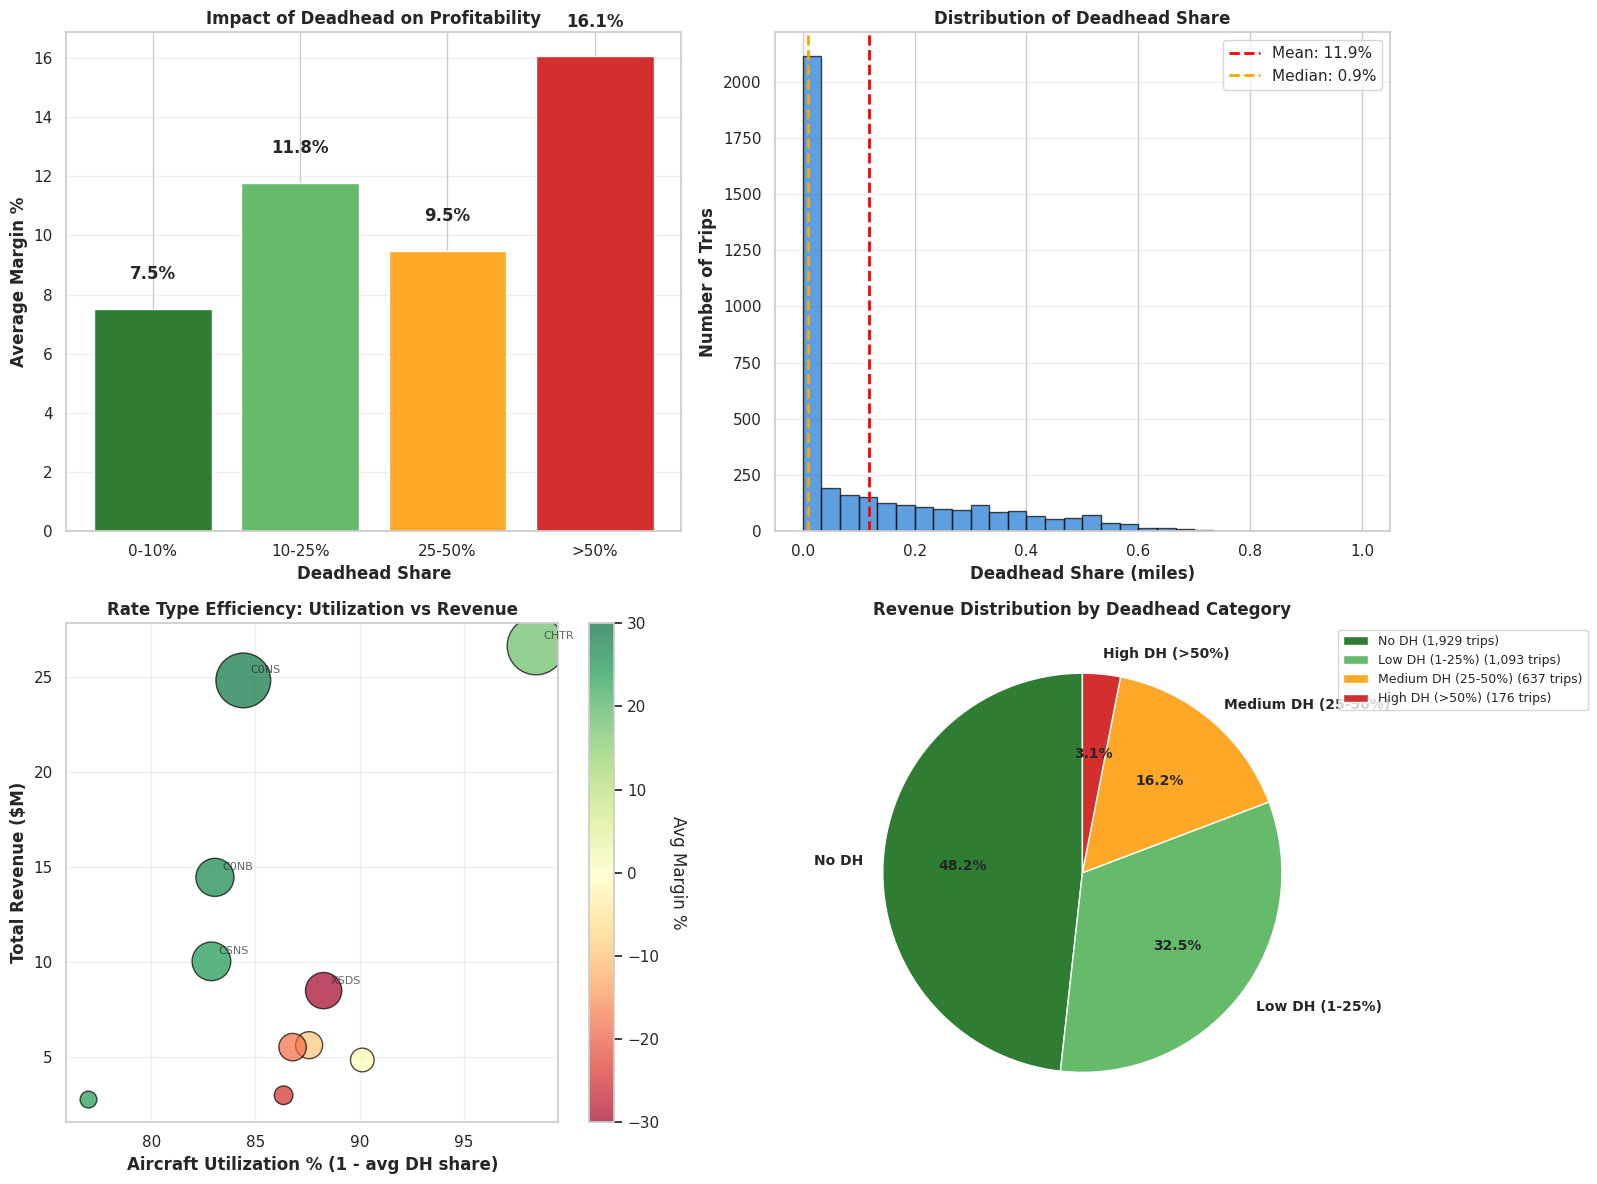

In [74]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Deadhead impact on margin
dh_bins = [0, 0.1, 0.25, 0.5, 1.0]
dh_labels = ['0-10%', '10-25%', '25-50%', '>50%']
dh_analysis['dh_bin'] = pd.cut(dh_analysis['dh_share_miles'], bins=dh_bins, labels=dh_labels)
dh_margin = dh_analysis.groupby('dh_bin')['margin_pct_vs_ac_cost'].mean() * 100

bars = axes[0,0].bar(range(len(dh_margin)), dh_margin.values, color=['#2E7D32', '#66BB6A', '#FFA726', '#D32F2F'])
axes[0,0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0,0].set_xticks(range(len(dh_margin)))
axes[0,0].set_xticklabels(dh_margin.index)
axes[0,0].set_xlabel('Deadhead Share', fontweight='bold')
axes[0,0].set_ylabel('Average Margin %', fontweight='bold')
axes[0,0].set_title('Impact of Deadhead on Profitability', fontsize=12, fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(dh_margin.values):
    axes[0,0].text(i, v + 1 if v > 0 else v - 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Deadhead distribution
axes[0,1].hist(dh_analysis['dh_share_miles'], bins=30, color='#1976D2', edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=dh_analysis['dh_share_miles'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Mean: {dh_analysis['dh_share_miles'].mean()*100:.1f}%")
axes[0,1].axvline(x=dh_analysis['dh_share_miles'].median(), color='orange', linestyle='--', linewidth=2,
                  label=f"Median: {dh_analysis['dh_share_miles'].median()*100:.1f}%")
axes[0,1].set_xlabel('Deadhead Share (miles)', fontweight='bold')
axes[0,1].set_ylabel('Number of Trips', fontweight='bold')
axes[0,1].set_title('Distribution of Deadhead Share', fontsize=12, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3, axis='y')

# 3. Revenue vs Utilization by rate type (top 10)
top_10_rates = rate_efficiency.head(10)
scatter = axes[1,0].scatter(
    top_10_rates['avg_utilization']*100,
    top_10_rates['total_revenue']/1000000,
    s=top_10_rates['n_trips']*2,
    c=top_10_rates['avg_margin_pct']*100,
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='black',
    linewidth=1,
    vmin=-30,
    vmax=30
)
axes[1,0].set_xlabel('Aircraft Utilization % (1 - avg DH share)', fontweight='bold')
axes[1,0].set_ylabel('Total Revenue ($M)', fontweight='bold')
axes[1,0].set_title('Rate Type Efficiency: Utilization vs Revenue', fontsize=12, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1,0])
cbar.set_label('Avg Margin %', rotation=270, labelpad=20)

# Add labels for key rate types
for idx, row in top_10_rates.head(5).iterrows():
    axes[1,0].annotate(
        row['qRate_Type_Code'],
        (row['avg_utilization']*100, row['total_revenue']/1000000),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.7
    )

# 4. Cost breakdown by deadhead category
dh_cost_data = dh_summary[['dh_category', 'n_trips', 'total_revenue']].copy()
colors_dh = ['#2E7D32', '#66BB6A', '#FFA726', '#D32F2F']
wedges, texts, autotexts = axes[1,1].pie(
    dh_cost_data['total_revenue'],
    labels=dh_cost_data['dh_category'],
    autopct='%1.1f%%',
    colors=colors_dh,
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
axes[1,1].set_title('Revenue Distribution by Deadhead Category', fontsize=12, fontweight='bold')

# Add trip counts to legend
legend_labels = [f"{cat} ({n:,} trips)" for cat, n in zip(dh_cost_data['dh_category'], dh_cost_data['n_trips'])]
axes[1,1].legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)

plt.tight_layout()
plt.show()

In [75]:
print('\n' + '='*80)
print('KEY DEADHEAD INSIGHTS:')
print('='*80)
print(f"Trips with no deadhead: {(dh_analysis['dh_share_miles'] == 0).sum()} ({(dh_analysis['dh_share_miles'] == 0).sum()/len(dh_analysis)*100:.1f}%)")
print(f"Average deadhead share: {dh_analysis['dh_share_miles'].mean()*100:.1f}%")
print(f"Margin difference (No DH vs High DH): {(dh_summary.iloc[0]['avg_margin_pct'] - dh_summary.iloc[-1]['avg_margin_pct'])*100:.1f} percentage points")
print(f"Most efficient rate type: {rate_efficiency.iloc[0]['qRate_Type_Code']} ({rate_efficiency.iloc[0]['avg_utilization']*100:.1f}% utilization)")


KEY DEADHEAD INSIGHTS:
Trips with no deadhead: 1858 (48.4%)
Average deadhead share: 11.9%
Margin difference (No DH vs High DH): -6.0 percentage points
Most efficient rate type: CHTR (98.5% utilization)
